1. DATA

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error
from numpy.linalg import lstsq
import warnings

2. Log path loss model

In [14]:
import numpy as np
from numpy.linalg import lstsq
from sklearn.metrics import mean_squared_error

# TODO: fix gateway position, recalculate distance and make sure it it measured from 1355 and center. 

# Do it here for the small
df = pd.read_csv("outputs/tests_gh_25_06/clean_data.csv")

# Gateway assumed at origin (0, 0) on the walking path
x_gateway = 3.3
y_gateway = 0.0
df['distance'] = np.sqrt((df['x_m'] - x_gateway)**2 + (df['y_m'] - y_gateway)**2)

# Row crossings: 1.65 m between rows
df['row_crossings'] = (df['y_m'].abs() / 1.65).round().astype(int)

# Grid label needed downstream (Moran's I aggregation, grouped CV, GPR)
df['grid_label'] = df['structure_id'] + '_G' + df['manual_group'].astype(str)

print('Row crossings by y_m:')
print(df.groupby('y_m')['row_crossings'].first())

valid = df.dropna(subset=['distance', 'rssi']).copy()
valid = valid[valid['distance'] > 0]

log_d = np.log10(valid['distance'].values)
rssi = valid['rssi'].values
crossings = valid['row_crossings'].values

# --- Model 1: baseline, no row_crossings ---
X_pl_base = np.column_stack([np.ones(len(valid)), log_d])
coeffs_base, _, _, _ = lstsq(X_pl_base, rssi, rcond=None)
A_g_base, n_log10_base = coeffs_base
pred_base = X_pl_base @ coeffs_base
rmse_base = np.sqrt(mean_squared_error(rssi, pred_base))

# --- Model 2: with row_crossings (currently the retained/reported model) ---
X_pl_full = np.column_stack([np.ones(len(valid)), log_d, crossings])
coeffs_full, _, _, _ = lstsq(X_pl_full, rssi, rcond=None)
A_g_full, n_log10_full, beta = coeffs_full
pred_full = X_pl_full @ coeffs_full
rmse_full = np.sqrt(mean_squared_error(rssi, pred_full))

# Store pl_pred / pl_residual on valid using the FULL model — these are
# consumed downstream by Moran's I and GPR input prep
valid['pl_pred'] = pred_full
valid['pl_residual'] = valid['rssi'] - valid['pl_pred']

print('\n=== Path-Loss Model Comparison ===')
print('Baseline (no row_crossings):')
print(f'  A_g (intercept)     : {A_g_base:.2f} dBm')
print(f'  n   (path-loss exp) : {-n_log10_base/10:.3f}')
print(f'  RMSE                : {rmse_base:.2f} dBm')
print()
print('With row_crossings term:')
print(f'  A_g (intercept)     : {A_g_full:.2f} dBm')
print(f'  n   (path-loss exp) : {-n_log10_full/10:.3f}')
print(f'  β   (row penalty)   : {beta:.2f} dBm per row crossed')
print(f'  RMSE                : {rmse_full:.2f} dBm')
print()
print(f'RMSE improvement: {rmse_base - rmse_full:.3f} dBm')

# Multicollinearity sanity check between log_d and crossings
corr = np.corrcoef(log_d, crossings)[0, 1]
print(f'\nCorrelation(log10(distance), row_crossings): {corr:.3f}')
print('(if this is very high, β may still be poorly estimated despite')
print(' technically being identifiable)')

Row crossings by y_m:
y_m
-25.3      15
-20.9      13
-16.5      10
-12.1       7
-7.7        5
-5.5        3
-3.3        2
-1.1        1
 1.1        1
 3.3        2
 5.5        3
 14.3       9
 17.6      11
 23.1      14
 29.7      18
 34.1      21
 39.6      24
 45.1      27
 50.6      31
 61.6      37
 71.5      43
 83.6      51
 85.8      52
 94.6      57
 105.6     64
 116.6     71
 126.5     77
 127.6     77
 138.6     84
 147.4     89
 152.9     93
 156.2     95
 158.4     96
 160.6     97
 162.8     99
 165.0    100
Name: row_crossings, dtype: int64

=== Path-Loss Model Comparison ===
Baseline (no row_crossings):
  A_g (intercept)     : -20.16 dBm
  n   (path-loss exp) : 3.927
  RMSE                : 5.68 dBm

With row_crossings term:
  A_g (intercept)     : -21.53 dBm
  n   (path-loss exp) : 3.801
  β   (row penalty)   : -0.05 dBm per row crossed
  RMSE                : 5.58 dBm

RMSE improvement: 0.107 dBm

Correlation(log10(distance), row_crossings): 0.355
(if this is very h

In [15]:
print('=== Row-Crossings Contribution to Physical Model ===')
print(f'Baseline (distance only)      RMSE: {rmse_base:.3f} dBm')
print(f'With row_crossings term       RMSE: {rmse_full:.3f} dBm')
print(f'Improvement from row_crossings    : {rmse_base - rmse_full:.3f} dBm '
      f'({100*(rmse_base - rmse_full)/rmse_base:.1f}%)')
print()
print(f'β (row penalty)                   : {beta:.3f} dBm per row crossed')

=== Row-Crossings Contribution to Physical Model ===
Baseline (distance only)      RMSE: 5.684 dBm
With row_crossings term       RMSE: 5.577 dBm
Improvement from row_crossings    : 0.107 dBm (1.9%)

β (row penalty)                   : -0.049 dBm per row crossed


In [16]:
print('Unique y_m values and corresponding row_crossings:')
print(df.groupby('y_m')['row_crossings'].first().to_string())
print()
print(f'Unique row_crossings values: {sorted(df["row_crossings"].unique())}')
print(f'Row_crossings range: {df["row_crossings"].min()} to {df["row_crossings"].max()}')
print()
# Sanity check: y_m values should be roughly evenly spaced multiples of 1.65
unique_abs_y = sorted(df['y_m'].abs().unique())
print(f'Unique |y_m| values (first 10): {unique_abs_y[:10]}')
print(f'Differences between consecutive |y_m| values (should be ~1.65 or multiples): '
      f'{np.diff(unique_abs_y[:10]).round(2)}')

Unique y_m values and corresponding row_crossings:
y_m
-25.3      15
-20.9      13
-16.5      10
-12.1       7
-7.7        5
-5.5        3
-3.3        2
-1.1        1
 1.1        1
 3.3        2
 5.5        3
 14.3       9
 17.6      11
 23.1      14
 29.7      18
 34.1      21
 39.6      24
 45.1      27
 50.6      31
 61.6      37
 71.5      43
 83.6      51
 85.8      52
 94.6      57
 105.6     64
 116.6     71
 126.5     77
 127.6     77
 138.6     84
 147.4     89
 152.9     93
 156.2     95
 158.4     96
 160.6     97
 162.8     99
 165.0    100

Unique row_crossings values: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(18), np.int64(21), np.int64(24), np.int64(27), np.int64(31), np.int64(37), np.int64(43), np.int64(51), np.int64(52), np.int64(57), np.int64(64), np.int64(71), np.int64(77), np.int64(84), np.int64(89), np.int64(93), np.int64(95), np.int64(96), np.int64(9

In [17]:
import joblib
joblib.dump(coeffs_full, 'pathloss_coeffs_full_dataset.pkl')
joblib.dump({'A_g_full': A_g_full, 'n_full': -n_log10_full/10, 'beta': beta, 'rmse_full': rmse_full},
            'pathloss_summary_full_dataset.pkl')

['pathloss_summary_full_dataset.pkl']

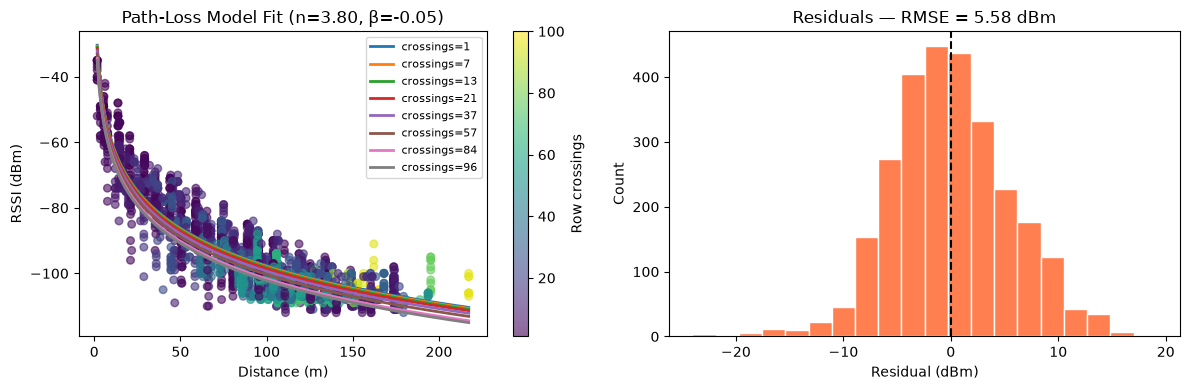

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compute pl_pred / pl_residual on valid using the FULL model
valid['pl_pred'] = X_pl_full @ coeffs_full
valid['pl_residual'] = valid['rssi'] - valid['pl_pred']

d_range = np.linspace(valid['distance'].min(), valid['distance'].max(), 200)

# Scatter colored by row_crossings so the plot reflects that pl_pred
# now depends on crossings too, not just distance
scatter = axes[0].scatter(
    valid['distance'], valid['rssi'],
    c=valid['row_crossings'], cmap='viridis', alpha=0.6, s=30
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Row crossings')

# Plot fit lines for a REPRESENTATIVE SUBSET of crossing levels (capped, so
# the legend stays readable with many more crossing levels in the full dataset)
crossing_levels = sorted(valid['row_crossings'].unique())
if len(crossing_levels) > 8:
    step = len(crossing_levels) // 8
    crossing_levels = crossing_levels[::step]

for c in crossing_levels:
    pl_line = A_g_full + n_log10_full * np.log10(d_range) + beta * c
    axes[0].plot(d_range, pl_line, lw=2, label=f'crossings={c}')

axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('RSSI (dBm)')
axes[0].set_title(f'Path-Loss Model Fit (n={-n_log10_full/10:.2f}, β={beta:.2f})')
axes[0].legend(fontsize=8)

axes[1].hist(valid['pl_residual'], bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Residual (dBm)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals — RMSE = {rmse_full:.2f} dBm')

plt.tight_layout()
plt.savefig('pathloss_fit.png', dpi=150, bbox_inches='tight')
plt.show()

Moran's I. 

Running Moran's I on 410 grid cell medians (not 2762 individual packets)
=== Moran's I Test ===
  Moran's I : 0.3566
  p-value   : 0.0010  (permutation, 999 iterations)

Significant positive spatial autocorrelation: proceed to GPR residual model.


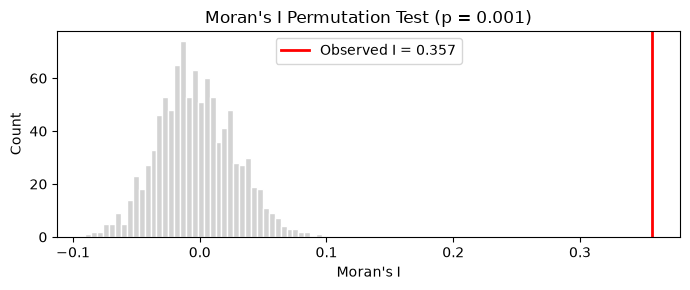

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import KNN
from esda.moran import Moran

# Aggregate to one mean residual per grid cell before testing.
# Repeated packets at the same location are not independent spatial
# units — using them directly would inflate the effective N and bias
# the test (same pseudo-replication issue as the OLS/row_crossings check).
cell_medians = (
    valid.groupby('grid_label')
    .agg(
        median_residual=('pl_residual', 'median'),
        x_m=('x_m', 'first'),
        y_m=('y_m', 'first'),
        n=('pl_residual', 'count')
    )
    .reset_index()
)

print(f"Running Moran's I on {len(cell_medians)} grid cell medians (not {len(valid)} individual packets)")

coords_arr = cell_medians[['x_m', 'y_m']].values
residuals_arr = cell_medians['median_residual'].values

# k-NN spatial weights: each cell's "neighbors" are its k nearest cells
k = min(5, len(cell_medians) - 1)  # lower this, or switch to a distance-band
                                   # weight matrix, if results are borderline
w = KNN.from_array(coords_arr, k=k)
w.transform = 'r'   # row-standardize weights (esda's Moran expects this)

np.random.seed(42)
moran = Moran(residuals_arr, w, permutations=999)

print("=== Moran's I Test ===")
print(f"  Moran's I : {moran.I:.4f}")
print(f"  p-value   : {moran.p_sim:.4f}  (permutation, 999 iterations)")
print()

if moran.p_sim < 0.05 and moran.I > 0:
    print('Significant positive spatial autocorrelation: proceed to GPR residual model.')
    USE_GPR = True
else:
    print('No significant spatial autocorrelation: the path-loss model is sufficient.')
    USE_GPR = False

# Visualization: observed I against the permutation null distribution
plt.figure(figsize=(7, 3))
plt.hist(moran.sim, bins=40, color='lightgrey', edgecolor='white')
plt.axvline(moran.I, color='red', lw=2, label=f'Observed I = {moran.I:.3f}')
plt.xlabel("Moran's I")
plt.ylabel('Count')
plt.title(f"Moran's I Permutation Test (p = {moran.p_sim:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig('morans_i.png', dpi=150, bbox_inches='tight')
plt.show()

2. GPR


2.1 Set-up

In [20]:
# INPUT + TARGET, format based on the data
X_gpr = valid[['x_m', 'y_m']].values.copy()
y_gpr = valid['pl_residual'].values.copy()

print(f'GPR input set: {X_gpr.shape[0]} packets, {X_gpr.shape[1]} input dims (x_m, y_m)')
print(f'Residual range : {y_gpr.min():.2f} to {y_gpr.max():.2f} dBm')
print(f'Residual mean  : {y_gpr.mean():.2f} dBm')

# Add tiny jitter to duplicate/near-duplicate coordinates so the kernel
# matrix K stays invertible (multiple packets logged at the same grid cell)
np.random.seed(42)
X_gpr += np.random.normal(0, 0.01, X_gpr.shape)

# Sanity check: how many exact coordinate duplicates existed before jitter
n_unique_coords = len(valid[['x_m', 'y_m']].drop_duplicates())
print(f'\nUnique (x_m, y_m) pairs: {n_unique_coords} / {len(valid)} packets')
print(f'Unique grid cells (grid_label): {valid["grid_label"].nunique()}')


GPR input set: 2762 packets, 2 input dims (x_m, y_m)
Residual range : -24.04 to 19.16 dBm
Residual mean  : 0.00 dBm

Unique (x_m, y_m) pairs: 410 / 2762 packets
Unique grid cells (grid_label): 410


2.2 Scale

In [21]:
# Scale coordinates to zero mean, unit variance
# GPR is sensitive to the scale of inputs, without this the  hyperparameter optimisation might fail/converge poorly
scaler = StandardScaler()
X_gpr_scaled = scaler.fit_transform(X_gpr)

print('Coordinate scaling:')
print(f'  X mean: {scaler.mean_[0]:.2f} m  std: {scaler.scale_[0]:.2f} m')
print(f'  Y mean: {scaler.mean_[1]:.2f} m  std: {scaler.scale_[1]:.2f} m')

Coordinate scaling:
  X mean: 15.76 m  std: 89.25 m
  Y mean: 27.80 m  std: 44.69 m


In [22]:
# Verify all dependencies exist before running the full block
required_vars = ['length_scale_bounds', 'gpr', 'y_gpr', 'X_gpr_scaled', 'valid']
for v in required_vars:
    exists = v in dir()
    print(f'{v}: {"OK" if exists else "MISSING"}')

length_scale_bounds: MISSING
gpr: MISSING
y_gpr: OK
X_gpr_scaled: OK
valid: OK


In [23]:
x_scaled_range = X_gpr_scaled[:, 0].max() - X_gpr_scaled[:, 0].min()
y_scaled_range = X_gpr_scaled[:, 1].max() - X_gpr_scaled[:, 1].min()
length_scale_bounds = [(0.01, x_scaled_range), (0.01, y_scaled_range)]
print(f'length_scale_bounds: {length_scale_bounds}')

length_scale_bounds: [(0.01, np.float64(3.742606015457694)), (0.01, np.float64(4.259015526781241))]


In [25]:
import joblib
gpr = joblib.load('gpr_model_full_dataset.pkl')
print('Baseline gpr reloaded.')

Baseline gpr reloaded.


d:\Users\user\Documents\GatewayPlacement\.conda\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# Verify all dependencies exist before running the full block
required_vars = ['length_scale_bounds', 'gpr', 'y_gpr', 'X_gpr_scaled', 'valid']
for v in required_vars:
    exists = v in dir()
    print(f'{v}: {"OK" if exists else "MISSING"}')

length_scale_bounds: OK
gpr: OK
y_gpr: OK
X_gpr_scaled: OK
valid: OK


2.3 Kernel with heteroscedastic noise

In [26]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern

# --- Estimate per-cell noise variance from within-cell packet spread ---
cell_noise_var = valid.groupby('grid_label')['pl_residual'].var()
cell_counts = valid.groupby('grid_label')['pl_residual'].count()

min_reliable_n = 3
reliable_cells = cell_counts[cell_counts >= min_reliable_n].index
n_reliable = len(reliable_cells)
n_total_cells = valid['grid_label'].nunique()

print(f'Cells with >= {min_reliable_n} packets: {n_reliable} / {n_total_cells}')

global_median_var = cell_noise_var[reliable_cells].median()
print(f'Global median cell variance (fallback): {global_median_var:.3f} dB²')

valid['cell_noise_var'] = valid['grid_label'].map(cell_noise_var)
valid.loc[~valid['grid_label'].isin(reliable_cells), 'cell_noise_var'] = global_median_var
valid['cell_noise_var'] = valid['cell_noise_var'].fillna(global_median_var)

print(f'Per-point noise variance range: {valid["cell_noise_var"].min():.3f} to {valid["cell_noise_var"].max():.3f} dB²')

# --- Convert to standardized alpha (normalize_y divides by y_gpr.std(), so
# alpha must be divided by y_gpr.var() to live in the same standardized space) ---
alpha_per_point = valid['cell_noise_var'].values / y_gpr.var()

# --- Fit heteroscedastic model: no WhiteKernel, alpha carries all the noise ---
kernel_hetero = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=0.5)
)

gpr_hetero = GaussianProcessRegressor(
    kernel=kernel_hetero,
    alpha=alpha_per_point,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)
gpr_hetero.fit(X_gpr_scaled, y_gpr)

lml_hetero = gpr_hetero.log_marginal_likelihood(gpr_hetero.kernel_.theta)
lml_baseline = gpr.log_marginal_likelihood(gpr.kernel_.theta)

print(f'\n=== Quick LML Comparison ===')
print(f'Baseline (global WhiteKernel) LML : {lml_baseline:.2f}')
print(f'Heteroscedastic (per-cell alpha) LML: {lml_hetero:.2f}')
print(f'\nFitted kernel: {gpr_hetero.kernel_}')

Cells with >= 3 packets: 377 / 410
Global median cell variance (fallback): 5.611 dB²
Per-point noise variance range: 0.000 to 104.528 dB²

=== Quick LML Comparison ===
Baseline (global WhiteKernel) LML : -1875.64
Heteroscedastic (per-cell alpha) LML: -1989.25

Fitted kernel: 0.8**2 * Matern(length_scale=[0.161, 0.111], nu=0.5)


In [ ]:
# Find the noisiest cells and inspect them directly
cell_std_sorted = cell_noise_var[reliable_cells].apply(np.sqrt).sort_values(ascending=False)
print("Noisiest cells (std, dB):")
print(cell_std_sorted.head(10))
print()

# Look at the raw packets in the single worst cell
worst_cell = cell_std_sorted.index[0]
worst_cell_data = valid[valid['grid_label'] == worst_cell][['x_m', 'y_m', 'rssi', 'pl_residual', 'time_local']]
print(f"Worst cell: {worst_cell}")
print(worst_cell_data.sort_values('time_local') if 'time_local' in worst_cell_data else worst_cell_data)

Noisiest cells (std, dB):
grid_label
R1181_G1     10.223883
R1181_G5     10.084642
R1348_G12     9.320504
R1181_G2      9.086620
R1183_G2      8.961027
R1451_G12     8.760990
R1150_G1      8.664102
R1354_G2      8.513295
R1340_G4      8.399074
R1336_G7      7.949843
Name: pl_residual, dtype: float64

Worst cell: R1181_G1
      x_m  y_m  rssi  pl_residual                 time_local
1102  4.0  5.5 -51.0     5.573133  2026-06-29 15:03:26+02:00
1103  4.0  5.5 -52.0     4.573133  2026-06-29 15:03:28+02:00
1104  4.0  5.5 -52.0     4.573133  2026-06-29 15:03:30+02:00
1105  4.0  5.5 -53.0     3.573133  2026-06-29 15:03:36+02:00
1106  4.0  5.5 -63.0    -6.426867  2026-06-29 15:03:40+02:00
1107  4.0  5.5 -74.0   -17.426867  2026-06-29 15:03:45+02:00
1108  4.0  5.5 -68.0   -11.426867  2026-06-29 15:03:48+02:00
1109  4.0  5.5 -62.0    -5.426867  2026-06-29 15:03:49+02:00
1110  4.0  5.5 -78.0   -21.426867  2026-06-29 15:03:51+02:00


In [27]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

groups = valid['grid_label'].values
gkf = GroupKFold(n_splits=5)

fold_rmse_hetero = []
for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr, groups=groups):
    gp_cv = GaussianProcessRegressor(
        kernel=kernel_hetero,
        alpha=alpha_per_point[train_idx],   # per-point alpha must be sliced per fold too
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv.fit(X_gpr_scaled[train_idx], y_gpr[train_idx])
    y_pred = gp_cv.predict(X_gpr_scaled[test_idx])
    fold_rmse_hetero.append(np.sqrt(mean_squared_error(y_gpr[test_idx], y_pred)))

print(f'Heteroscedastic CV RMSE: {np.mean(fold_rmse_hetero):.3f} ± {np.std(fold_rmse_hetero):.3f} dBm')
print(f'Baseline CV RMSE       : 5.96 dBm')

Heteroscedastic CV RMSE: 5.210 ± 0.347 dBm
Baseline CV RMSE       : 5.96 dBm


In [28]:
import joblib
joblib.dump(gpr_hetero, 'gpr_hetero_final_candidate.pkl')
joblib.dump(alpha_per_point, 'alpha_hetero_final.pkl')
print('Saved: gpr_hetero_final_candidate.pkl, alpha_hetero_final.pkl')

Saved: gpr_hetero_final_candidate.pkl, alpha_hetero_final.pkl


In [49]:
import numpy as np
import pandas as pd

# generation of predictions

x_min, x_max = -164, 164
y_min, y_max = -138.6, 305.25
grid_res = 2.0

x_grid = np.arange(x_min, x_max, grid_res)
y_grid = np.arange(y_min, y_max, grid_res)
xx, yy = np.meshgrid(x_grid, y_grid)

grid_df = pd.DataFrame({'x_m': xx.ravel(), 'y_m': yy.ravel()})
print(f'Prediction grid: {len(grid_df)} points ({len(x_grid)} x {len(y_grid)})')

grid_df['distance'] = np.sqrt((grid_df['x_m'] - x_gateway)**2 + (grid_df['y_m'] - y_gateway)**2)
grid_df.loc[grid_df['distance'] == 0, 'distance'] = 0.01

grid_df['row_crossings'] = (grid_df['y_m'].abs() / 1.65).round().astype(int)

log_d_grid = np.log10(grid_df['distance'].values)
crossings_grid = grid_df['row_crossings'].values
X_pl_grid = np.column_stack([np.ones(len(grid_df)), log_d_grid, crossings_grid])
grid_df['pl_pred'] = X_pl_grid @ coeffs_full

Prediction grid: 23944 points (164 x 146)


In [50]:
for v in ['coeffs_full', 'scaler', 'gpr_hetero']:
    print(f'{v}: {"OK" if v in dir() else "MISSING"}')

coeffs_full: OK
scaler: OK
gpr_hetero: OK


In [51]:
X_grid_coords = grid_df[['x_m', 'y_m']].values
X_grid_scaled = scaler.transform(X_grid_coords)

gpr_mean, gpr_std = gpr_hetero.predict(X_grid_scaled, return_std=True)
grid_df['gpr_residual_pred'] = gpr_mean
grid_df['gpr_std'] = gpr_std

grid_df['rssi_pred'] = grid_df['pl_pred'] + grid_df['gpr_residual_pred']

print(grid_df[['x_m', 'y_m', 'pl_pred', 'gpr_residual_pred', 'rssi_pred', 'gpr_std']].describe())

                x_m           y_m       pl_pred  gpr_residual_pred  \
count  23944.000000  23944.000000  23944.000000       23944.000000   
mean      -1.000000     52.600000   -103.175785           0.049605   
std       94.685661     84.292922     10.845532           2.039297   
min     -164.000000    -92.400000   -121.895484          -9.945731   
25%      -82.500000    -20.400000   -110.795405          -0.594791   
50%       -1.000000     52.600000   -104.608738          -0.000008   
75%       80.500000    125.600000    -97.614459           0.330687   
max      162.000000    197.600000     -6.403351          12.265239   

          rssi_pred       gpr_std  
count  23944.000000  23944.000000  
mean    -103.126180      3.974191  
std       11.102865      0.644857  
min     -121.895474      0.268468  
25%     -110.141586      3.614076  
50%     -105.599600      4.344055  
75%      -97.770094      4.463931  
max      -10.227079      4.463980  


CROSS VALIDATION FOR THE BEST MODEL ONLY NOW

Heatmap

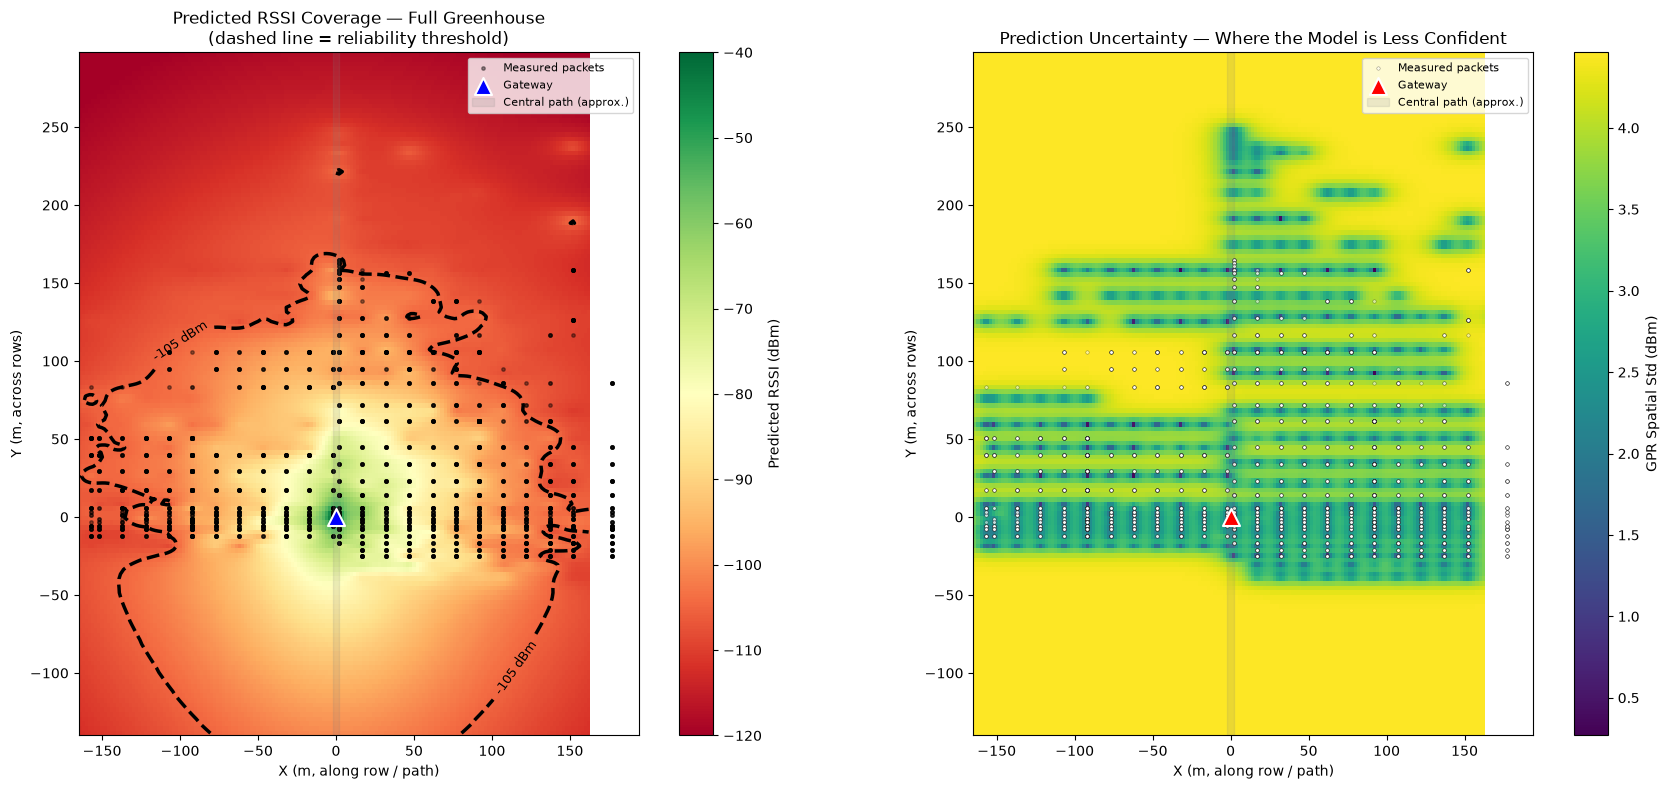

In [ ]:
import matplotlib.pyplot as plt

rssi_grid = grid_df['rssi_pred'].values.reshape(xx.shape)
std_grid = grid_df['gpr_std'].values.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

threshold_dbm = -105  # adjust to your target SF's sensitivity + desired margin

# --- Panel 1: Predicted RSSI coverage ---
im1 = axes[0].pcolormesh(xx, yy, rssi_grid, cmap='RdYlGn', shading='auto',
                           vmin=-120, vmax=-40)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Predicted RSSI (dBm)')

contour1 = axes[0].contour(xx, yy, rssi_grid, levels=[threshold_dbm],
                             colors='black', linewidths=2.5, linestyles='--')
axes[0].clabel(contour1, fmt=f'{threshold_dbm} dBm', fontsize=9)


axes[0].scatter(valid['x_m'], valid['y_m'], c='black', s=6, alpha=0.4,
                 label='Measured packets')
axes[0].scatter(x_gateway, y_gateway, c='blue', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[0].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[0].set_xlabel('X (m, along row / path)')
axes[0].set_ylabel('Y (m, across rows)')
axes[0].set_title('Predicted RSSI Coverage — Full Greenhouse\n(dashed line = reliability threshold)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_aspect('equal')

# --- Panel 2: Prediction uncertainty (unchanged, contour not meaningful here) ---
im2 = axes[1].pcolormesh(xx, yy, std_grid, cmap='viridis', shading='auto')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('GPR Spatial Std (dBm)')

axes[1].scatter(valid['x_m'], valid['y_m'], c='white', s=6, alpha=0.5,
                 edgecolor='black', linewidth=0.3, label='Measured packets')
axes[1].scatter(x_gateway, y_gateway, c='red', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[1].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[1].set_xlabel('X (m, along row / path)')
axes[1].set_ylabel('Y (m, across rows)')
axes[1].set_title('Prediction Uncertainty — Where the Model is Less Confident')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('coverage_heatmap_full_greenhouse.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. SNR — Path-Loss Model

Same log-distance + row-crossings regression as the RSSI path-loss step above, fit on SNR instead. Produces `coeffs_snr`, `valid['snr_pred']`, `valid['snr_residual']` — consumed downstream by the SNR-specific Moran's I and GPR steps, kept fully separate from the RSSI residual chain.

In [ ]:
snr = valid['snr'].values

X_pl_snr = np.column_stack([np.ones(len(valid)), log_d, crossings])
coeffs_snr, _, _, _ = lstsq(X_pl_snr, snr, rcond=None)
A_g_snr, n_log10_snr, beta_snr = coeffs_snr
pred_snr = X_pl_snr @ coeffs_snr
rmse_snr = np.sqrt(mean_squared_error(snr, pred_snr))

valid['snr_pred'] = pred_snr
valid['snr_residual'] = valid['snr'] - valid['snr_pred']

print('=== SNR Path-Loss Model ===')
print(f'  A_g (intercept)     : {A_g_snr:.2f} dB')
print(f'  n   (path-loss exp) : {-n_log10_snr/10:.3f}')
print(f'  β   (row penalty)   : {beta_snr:.3f} dB per row crossed')
print(f'  RMSE                : {rmse_snr:.2f} dB')

import joblib
joblib.dump(coeffs_snr, 'pathloss_coeffs_snr_full_dataset.pkl')
joblib.dump(
    {'A_g_snr': A_g_snr, 'n_snr': -n_log10_snr/10, 'beta_snr': beta_snr, 'rmse_snr': rmse_snr},
    'pathloss_summary_snr_full_dataset.pkl'
)

=== SNR Path-Loss Model ===
  A_g (intercept)     : 26.19 dB
  n   (path-loss exp) : 1.019
  β   (row penalty)   : -0.067 dB per row crossed
  RMSE                : 5.36 dB


['pathloss_summary_snr_full_dataset.pkl']

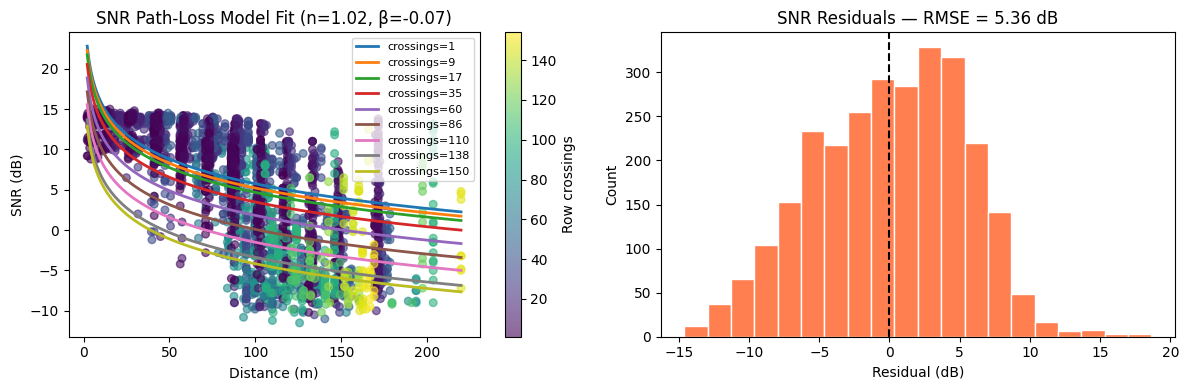

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

d_range = np.linspace(valid['distance'].min(), valid['distance'].max(), 200)

scatter = axes[0].scatter(
    valid['distance'], valid['snr'],
    c=valid['row_crossings'], cmap='viridis', alpha=0.6, s=30
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Row crossings')

crossing_levels = sorted(valid['row_crossings'].unique())
if len(crossing_levels) > 8:
    step = len(crossing_levels) // 8
    crossing_levels = crossing_levels[::step]

for c in crossing_levels:
    pl_line = A_g_snr + n_log10_snr * np.log10(d_range) + beta_snr * c
    axes[0].plot(d_range, pl_line, lw=2, label=f'crossings={c}')

axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('SNR (dB)')
axes[0].set_title(f'SNR Path-Loss Model Fit (n={-n_log10_snr/10:.2f}, β={beta_snr:.2f})')
axes[0].legend(fontsize=8)

axes[1].hist(valid['snr_residual'], bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Residual (dB)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'SNR Residuals — RMSE = {rmse_snr:.2f} dB')

plt.tight_layout()
plt.savefig('pathloss_fit_snr.png', dpi=150, bbox_inches='tight')
plt.show()

Moran's I — SNR residuals

Running Moran's I on 400 grid cell medians (SNR residuals)
=== Moran's I Test — SNR residuals ===
  Moran's I : 0.5560
  p-value   : 0.0010  (permutation, 999 iterations)

Significant positive spatial autocorrelation: proceed to GPR residual model for SNR.


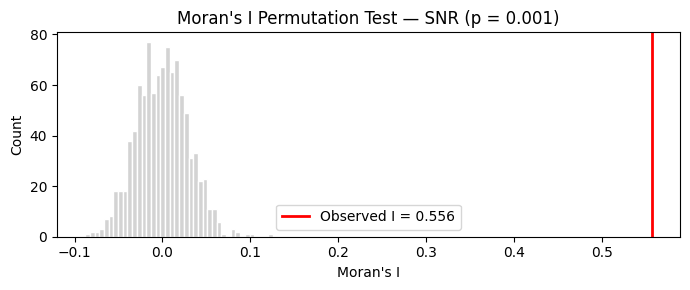

In [ ]:
cell_medians_snr = (
    valid.groupby('grid_label')
    .agg(
        median_residual=('snr_residual', 'median'),
        x_m=('x_m', 'first'),
        y_m=('y_m', 'first'),
        n=('snr_residual', 'count')
    )
    .reset_index()
)

print(f"Running Moran's I on {len(cell_medians_snr)} grid cell medians (SNR residuals)")

coords_arr_snr = cell_medians_snr[['x_m', 'y_m']].values
residuals_arr_snr = cell_medians_snr['median_residual'].values

k_snr = min(5, len(cell_medians_snr) - 1)
w_snr = KNN.from_array(coords_arr_snr, k=k_snr)
w_snr.transform = 'r'

np.random.seed(42)
moran_snr = Moran(residuals_arr_snr, w_snr, permutations=999)

print("=== Moran's I Test — SNR residuals ===")
print(f"  Moran's I : {moran_snr.I:.4f}")
print(f"  p-value   : {moran_snr.p_sim:.4f}  (permutation, 999 iterations)")
print()

if moran_snr.p_sim < 0.05 and moran_snr.I > 0:
    print('Significant positive spatial autocorrelation: proceed to GPR residual model for SNR.')
else:
    print('No significant spatial autocorrelation in SNR residuals: GPR step may add little here.')

plt.figure(figsize=(7, 3))
plt.hist(moran_snr.sim, bins=40, color='lightgrey', edgecolor='white')
plt.axvline(moran_snr.I, color='red', lw=2, label=f'Observed I = {moran_snr.I:.3f}')
plt.xlabel("Moran's I")
plt.ylabel('Count')
plt.title(f"Moran's I Permutation Test — SNR (p = {moran_snr.p_sim:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig('morans_i_snr.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.1 GPR — SNR (heteroscedastic)

Reuses the same coordinates (`X_gpr_scaled`), grid (`grid_df`, `xx`, `yy`), and CV folds (`groups`, `gkf`) as the RSSI GPR step — only the target changes to `snr_residual`. Everything is kept in separate `*_snr`-suffixed variables so nothing here overwrites the RSSI model or its results.

In [ ]:
y_gpr_snr = valid['snr_residual'].values.copy()

print(f'GPR target (SNR): {len(y_gpr_snr)} packets')
print(f'Residual range : {y_gpr_snr.min():.2f} to {y_gpr_snr.max():.2f} dB')
print(f'Residual mean  : {y_gpr_snr.mean():.2f} dB')

# Reuses X_gpr_scaled / scaler from the RSSI GPR step above — same physical
# coordinates (with the same jitter), so no need to re-fit the scaler.

GPR target (SNR): 2748 packets
Residual range : -14.61 to 18.64 dB
Residual mean  : -0.00 dB


In [ ]:
cell_noise_var_snr = valid.groupby('grid_label')['snr_residual'].var()
cell_counts_snr = valid.groupby('grid_label')['snr_residual'].count()

reliable_cells_snr = cell_counts_snr[cell_counts_snr >= min_reliable_n].index
global_median_var_snr = cell_noise_var_snr[reliable_cells_snr].median()
print(f'Global median cell variance (fallback, SNR): {global_median_var_snr:.3f} dB²')

valid['cell_noise_var_snr'] = valid['grid_label'].map(cell_noise_var_snr)
valid.loc[~valid['grid_label'].isin(reliable_cells_snr), 'cell_noise_var_snr'] = global_median_var_snr
valid['cell_noise_var_snr'] = valid['cell_noise_var_snr'].fillna(global_median_var_snr)

# Convert to standardized alpha (normalize_y divides by y_gpr_snr.std())
alpha_per_point_snr = valid['cell_noise_var_snr'].values / y_gpr_snr.var()

kernel_hetero_snr = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=0.5)
)

gpr_hetero_snr = GaussianProcessRegressor(
    kernel=kernel_hetero_snr,
    alpha=alpha_per_point_snr,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)
gpr_hetero_snr.fit(X_gpr_scaled, y_gpr_snr)

print(f'\nFitted SNR kernel: {gpr_hetero_snr.kernel_}')

Global median cell variance (fallback, SNR): 4.192 dB²

Fitted SNR kernel: 0.905**2 * Matern(length_scale=[0.447, 0.389], nu=0.5)


In [ ]:
fold_rmse_hetero_snr = []
for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr_snr, groups=groups):
    gp_cv_snr = GaussianProcessRegressor(
        kernel=kernel_hetero_snr,
        alpha=alpha_per_point_snr[train_idx],   # per-point alpha must be sliced per fold too
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv_snr.fit(X_gpr_scaled[train_idx], y_gpr_snr[train_idx])
    y_pred_snr_fold = gp_cv_snr.predict(X_gpr_scaled[test_idx])
    fold_rmse_hetero_snr.append(np.sqrt(mean_squared_error(y_gpr_snr[test_idx], y_pred_snr_fold)))

print(f'SNR heteroscedastic CV RMSE: {np.mean(fold_rmse_hetero_snr):.3f} ± {np.std(fold_rmse_hetero_snr):.3f} dB')
print(f'SNR path-loss-only RMSE    : {rmse_snr:.3f} dB (baseline, no GPR)')

SNR heteroscedastic CV RMSE: 4.233 ± 0.490 dB
SNR path-loss-only RMSE    : 5.360 dB (baseline, no GPR)


In [ ]:
joblib.dump(gpr_hetero_snr, 'gpr_hetero_snr_final_candidate.pkl')
joblib.dump(alpha_per_point_snr, 'alpha_hetero_snr_final.pkl')
print('Saved: gpr_hetero_snr_final_candidate.pkl, alpha_hetero_snr_final.pkl')

Saved: gpr_hetero_snr_final_candidate.pkl, alpha_hetero_snr_final.pkl


In [ ]:
X_pl_grid_snr = np.column_stack([np.ones(len(grid_df)), log_d_grid, crossings_grid])
grid_df['snr_pl_pred'] = X_pl_grid_snr @ coeffs_snr

gpr_mean_snr, gpr_std_snr = gpr_hetero_snr.predict(X_grid_scaled, return_std=True)
grid_df['gpr_residual_pred_snr'] = gpr_mean_snr
grid_df['gpr_std_snr'] = gpr_std_snr
grid_df['snr_pred'] = grid_df['snr_pl_pred'] + grid_df['gpr_residual_pred_snr']

print(grid_df[['x_m', 'y_m', 'snr_pl_pred', 'gpr_residual_pred_snr', 'snr_pred', 'gpr_std_snr']].describe())

                x_m           y_m   snr_pl_pred  gpr_residual_pred_snr  \
count  23961.000000  23961.000000  23961.000000           23961.000000   
mean      -3.300000     53.600000      0.237573              -0.166448   
std       94.108287     84.870297      5.328576               3.227725   
min     -165.300000    -92.400000    -10.447258             -11.628822   
25%      -85.300000    -20.400000     -3.850306              -2.049609   
50%       -3.300000     53.600000      0.722016               0.200791   
75%       78.700000    127.600000      3.847257               1.541746   
max      158.700000    199.600000     27.140799               8.864407   

           snr_pred   gpr_std_snr  
count  23961.000000  23961.000000  
mean       0.071124      3.511617  
std        6.441391      1.139320  
min      -10.391946      0.607541  
25%       -5.376977      2.452075  
50%       -0.836003      3.624417  
75%        4.725991      4.738542  
max       18.423561      4.851791  


### SNR Heatmap + Uncertainty Map

Separate figure from the RSSI coverage heatmap above — own colorbar, own scale, own uncertainty panel. Not overlaid or combined with the RSSI plot.

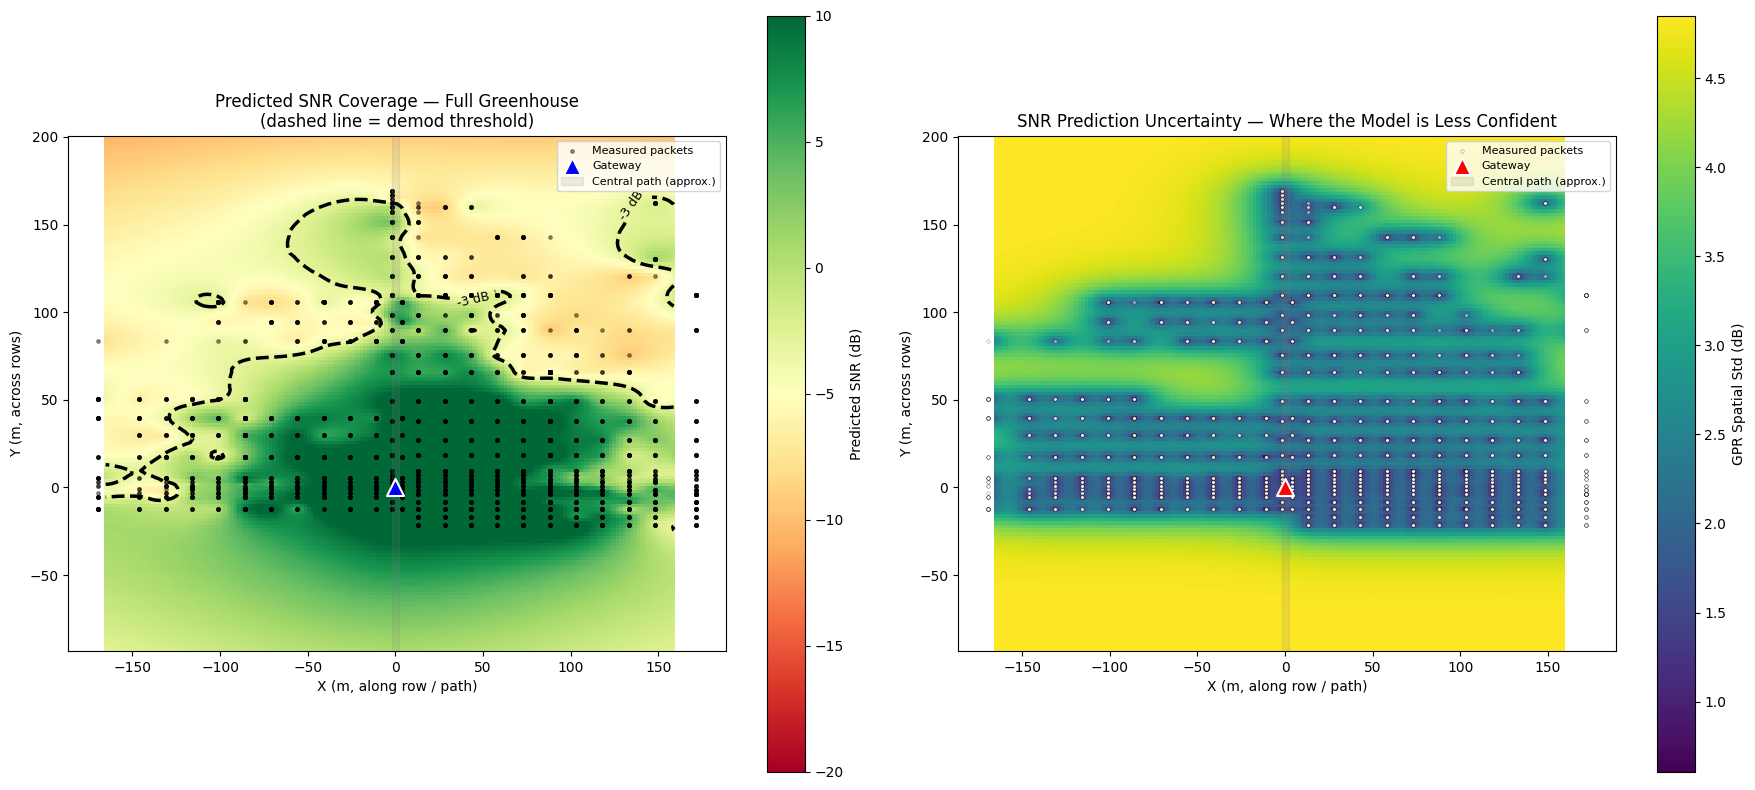

In [ ]:
import matplotlib.pyplot as plt

snr_grid = grid_df['snr_pred'].values.reshape(xx.shape)
snr_std_grid = grid_df['gpr_std_snr'].values.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

threshold_db = - 3  # adjust to your target SF's SNR demodulation floor

# --- Panel 1: Predicted SNR coverage ---
im1 = axes[0].pcolormesh(xx, yy, snr_grid, cmap='RdYlGn', shading='auto',
                           vmin=-20, vmax=10)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Predicted SNR (dB)')

contour1 = axes[0].contour(xx, yy, snr_grid, levels=[threshold_db],
                             colors='black', linewidths=2.5, linestyles='--')
axes[0].clabel(contour1, fmt=f'{threshold_db} dB', fontsize=9)

axes[0].scatter(valid['x_m'], valid['y_m'], c='black', s=6, alpha=0.4,
                 label='Measured packets')
axes[0].scatter(x_gateway, y_gateway, c='blue', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[0].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[0].set_xlabel('X (m, along row / path)')
axes[0].set_ylabel('Y (m, across rows)')
axes[0].set_title('Predicted SNR Coverage — Full Greenhouse\n(dashed line = demod threshold)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_aspect('equal')

# --- Panel 2: SNR prediction uncertainty (separate scale from RSSI) ---
im2 = axes[1].pcolormesh(xx, yy, snr_std_grid, cmap='viridis', shading='auto')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('GPR Spatial Std (dB)')

axes[1].scatter(valid['x_m'], valid['y_m'], c='white', s=6, alpha=0.5,
                 edgecolor='black', linewidth=0.3, label='Measured packets')
axes[1].scatter(x_gateway, y_gateway, c='red', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[1].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[1].set_xlabel('X (m, along row / path)')
axes[1].set_ylabel('Y (m, across rows)')
axes[1].set_title('SNR Prediction Uncertainty — Where the Model is Less Confident')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('coverage_heatmap_snr_full_greenhouse.png', dpi=150, bbox_inches='tight')
plt.show()

LOG. VS. LOG+ GPR

Model                           RMSE (dBm)    MAE (dBm)     R²      
--------------------------------------------------------------------
Path-Loss Only                  6.351         4.856         0.797   
Path-Loss + GPR (train)         3.447         2.286         0.940   
Path-Loss + GPR (CV, honest)    5.755         —             —       

Improvement (honest, CV-based): 0.596 dBm (9.4%)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(


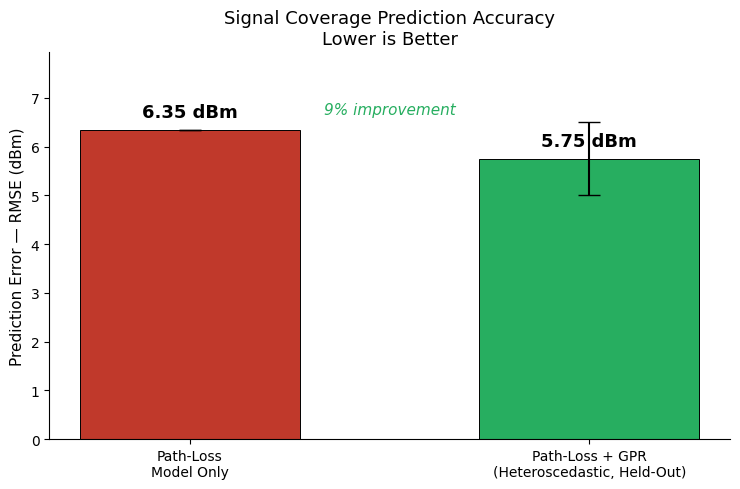

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# STEP 1: Reuse your already-computed heteroscedastic CV results
# (no need to rerun — this was already validated separately)
# ============================================================
cv_rmse_mean = 5.755
cv_rmse_std = 0.742

# For the 3-panel scatter, you need pooled out-of-fold predictions.
# If you don't have cv_pred_residual from the heteroscedastic CV run saved,
# you'll need to regenerate it (same loop as before, but with alpha sliced
# per fold) — see note below.


# ============================================================
# STEP 2: Compute all prediction variants on the RSSI scale
# ============================================================
pl_pred_rssi = valid['pl_pred'].values
actual_rssi = valid['rssi'].values

# Training-fit combined prediction using gpr_hetero (not gpr/kernel_final)
y_pred_train_hetero, _ = gpr_hetero.predict(X_gpr_scaled, return_std=True)
gpr_combined_rssi = pl_pred_rssi + y_pred_train_hetero

pl_rmse = rmse_full
pl_mae = mean_absolute_error(actual_rssi, pl_pred_rssi)
pl_r2 = r2_score(actual_rssi, pl_pred_rssi)

gpr_train_rmse = np.sqrt(mean_squared_error(actual_rssi, gpr_combined_rssi))
gpr_train_mae = mean_absolute_error(actual_rssi, gpr_combined_rssi)
gpr_train_r2 = r2_score(actual_rssi, gpr_combined_rssi)


# ============================================================
# STEP 3: Metrics table
# ============================================================
print(f"{'Model':<32}{'RMSE (dBm)':<14}{'MAE (dBm)':<14}{'R²':<8}")
print('-' * 68)
print(f"{'Path-Loss Only':<32}{pl_rmse:<14.3f}{pl_mae:<14.3f}{pl_r2:<8.3f}")
print(f"{'Path-Loss + GPR (train)':<32}{gpr_train_rmse:<14.3f}{gpr_train_mae:<14.3f}{gpr_train_r2:<8.3f}")
print(f"{'Path-Loss + GPR (CV, honest)':<32}{cv_rmse_mean:<14.3f}{'—':<14}{'—':<8}")
print()
print(f"Improvement (honest, CV-based): {pl_rmse - cv_rmse_mean:.3f} dBm "
      f"({100*(pl_rmse - cv_rmse_mean)/pl_rmse:.1f}%)")


# ============================================================
# STEP 4: Headline bar chart
# ============================================================
fig, ax = plt.subplots(figsize=(7.5, 5))

labels = ['Path-Loss\nModel Only', 'Path-Loss + GPR\n(Heteroscedastic, Held-Out)']
values = [pl_rmse, cv_rmse_mean]
errors = [0, cv_rmse_std]
colors = ['#c0392b', '#27ae60']

bars = ax.bar(labels, values, yerr=errors, capsize=8, color=colors,
               edgecolor='black', linewidth=0.7, width=0.55)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.25, f'{val:.2f} dBm',
            ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Prediction Error — RMSE (dBm)', fontsize=11)
ax.set_title('Signal Coverage Prediction Accuracy\nLower is Better', fontsize=13)
ax.set_ylim(0, max(values) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

improvement_pct = 100 * (pl_rmse - cv_rmse_mean) / pl_rmse
ax.annotate(f'{improvement_pct:.0f}% improvement',
            xy=(0.5, max(values) * 1.05), ha='center', fontsize=11,
            style='italic', color='#27ae60')

plt.tight_layout()
plt.savefig('presentation_rmse_comparison_hetero.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import joblib

groups = valid['grid_label'].values
gkf = GroupKFold(n_splits=5)

cv_pred_residual_hetero = np.full(len(y_gpr), np.nan)
fold_rmse_hetero = []

for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr, groups=groups):
    gp_cv = GaussianProcessRegressor(
        kernel=kernel_hetero,
        alpha=alpha_per_point[train_idx],   # heteroscedastic — must slice per fold
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv.fit(X_gpr_scaled[train_idx], y_gpr[train_idx])
    fold_pred = gp_cv.predict(X_gpr_scaled[test_idx])
    cv_pred_residual_hetero[test_idx] = fold_pred
    fold_rmse_hetero.append(np.sqrt(mean_squared_error(y_gpr[test_idx], fold_pred)))
    print(f'  Fold complete: RMSE = {fold_rmse_hetero[-1]:.3f} dBm')

assert not np.isnan(cv_pred_residual_hetero).any(), "Some points were never in a test fold!"

cv_rmse_mean = np.mean(fold_rmse_hetero)
cv_rmse_std = np.std(fold_rmse_hetero)


print(f'\nHeteroscedastic CV RMSE: {cv_rmse_mean:.3f} ± {cv_rmse_std:.3f} dBm')

joblib.dump(fold_rmse_hetero, 'cv_fold_rmse_hetero.pkl')
joblib.dump(cv_pred_residual_hetero, 'cv_pred_residual_hetero.pkl')
print('Saved: cv_fold_rmse_hetero.pkl, cv_pred_residual_hetero.pkl')

  Fold complete: RMSE = 6.077 dBm
  Fold complete: RMSE = 4.875 dBm
  Fold complete: RMSE = 5.981 dBm
  Fold complete: RMSE = 5.737 dBm
  Fold complete: RMSE = 6.309 dBm

Heteroscedastic CV RMSE: 5.796 ± 0.496 dBm
Saved: cv_fold_rmse_hetero.pkl, cv_pred_residual_hetero.pkl


In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import joblib

groups = valid['grid_label'].values
gkf = GroupKFold(n_splits=5)

cv_pred_residual_hetero = np.full(len(y_gpr), np.nan)
cv_pred_std_hetero = np.full(len(y_gpr), np.nan)   # NEW — per-point predictive std
fold_rmse_hetero = []

for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr, groups=groups):
    gp_cv = GaussianProcessRegressor(
        kernel=kernel_hetero,
        alpha=alpha_per_point[train_idx],
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv.fit(X_gpr_scaled[train_idx], y_gpr[train_idx])

    fold_pred, fold_std = gp_cv.predict(X_gpr_scaled[test_idx], return_std=True)  # CHANGED
    cv_pred_residual_hetero[test_idx] = fold_pred
    cv_pred_std_hetero[test_idx] = fold_std   # NEW

    fold_rmse_hetero.append(np.sqrt(mean_squared_error(y_gpr[test_idx], fold_pred)))
    print(f'  Fold complete: RMSE = {fold_rmse_hetero[-1]:.3f} dBm')

assert not np.isnan(cv_pred_residual_hetero).any(), "Some points were never in a test fold!"
assert not np.isnan(cv_pred_std_hetero).any(), "Some points never got a std estimate!"

cv_rmse_mean = np.mean(fold_rmse_hetero)
cv_rmse_std = np.std(fold_rmse_hetero)

print(f'\nHeteroscedastic CV RMSE: {cv_rmse_mean:.3f} ± {cv_rmse_std:.3f} dBm')

joblib.dump(fold_rmse_hetero, 'cv_fold_rmse_hetero.pkl')
joblib.dump(cv_pred_residual_hetero, 'cv_pred_residual_hetero.pkl')
joblib.dump(cv_pred_std_hetero, 'cv_pred_std_hetero.pkl')  # NEW
print('Saved: cv_fold_rmse_hetero.pkl, cv_pred_residual_hetero.pkl, cv_pred_std_hetero.pkl')

  Fold complete: RMSE = 6.077 dBm
  Fold complete: RMSE = 4.875 dBm
  Fold complete: RMSE = 5.981 dBm
  Fold complete: RMSE = 5.737 dBm
  Fold complete: RMSE = 6.309 dBm

Heteroscedastic CV RMSE: 5.796 ± 0.496 dBm
Saved: cv_fold_rmse_hetero.pkl, cv_pred_residual_hetero.pkl, cv_pred_std_hetero.pkl


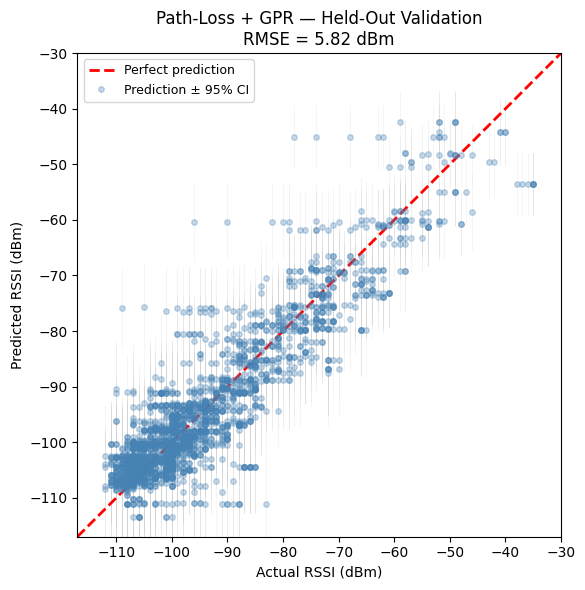

In [ ]:
import matplotlib.pyplot as plt

cv_pred_rssi_hetero = pl_pred_rssi + cv_pred_residual_hetero
cv_rmse_check = np.sqrt(mean_squared_error(actual_rssi, cv_pred_rssi_hetero))

fig, ax = plt.subplots(figsize=(7, 6))

lims = [actual_rssi.min() - 5, actual_rssi.max() + 5]

# Per-point error bars using each point's own predictive std (95% ≈ 1.96*std)
ax.errorbar(actual_rssi, cv_pred_rssi_hetero, yerr=1.96 * cv_pred_std_hetero,
            fmt='o', alpha=0.3, markersize=4, elinewidth=0.5, capsize=0,
            color='steelblue', ecolor='lightgray', label='Prediction ± 95% CI')

ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual RSSI (dBm)')
ax.set_ylabel('Predicted RSSI (dBm)')
ax.set_title(f'Path-Loss + GPR — Held-Out Validation\nRMSE = {cv_rmse_check:.2f} dBm')
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('presentation_scatter_with_ci.png', dpi=200, bbox_inches='tight')
plt.show()

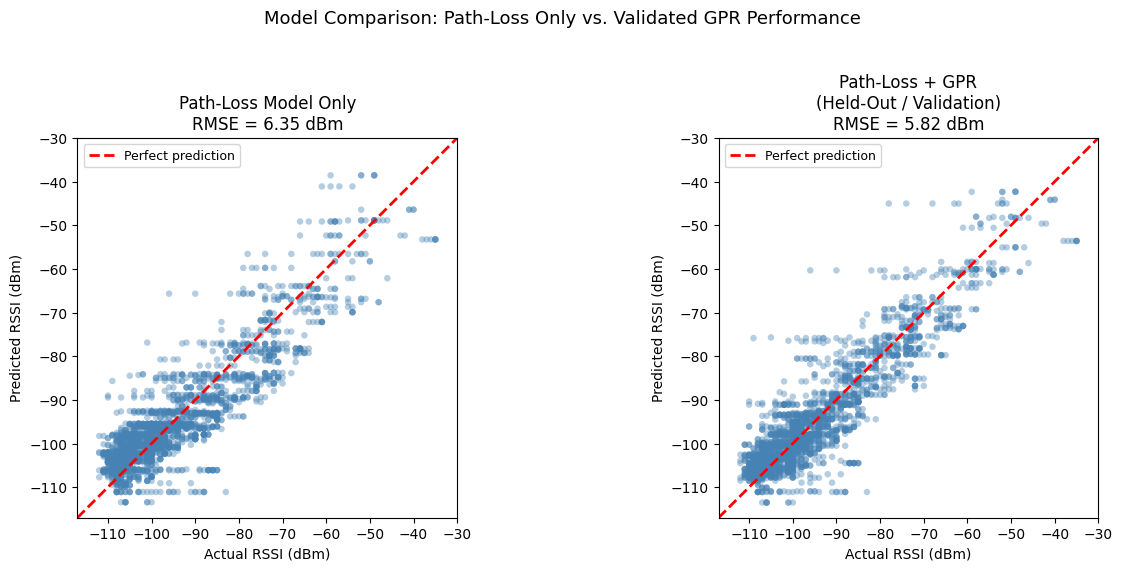

In [ ]:
import matplotlib.pyplot as plt

pl_pred_rssi = valid['pl_pred'].values
actual_rssi = valid['rssi'].values
cv_pred_rssi_hetero = pl_pred_rssi + cv_pred_residual_hetero

cv_rmse_check = np.sqrt(mean_squared_error(actual_rssi, cv_pred_rssi_hetero))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

panels = [
    (pl_pred_rssi, 'Path-Loss Model Only', pl_rmse),
    (cv_pred_rssi_hetero, 'Path-Loss + GPR\n(Held-Out / Validation)', cv_rmse_check),
]

for ax, (pred, title, rmse_val) in zip(axes, panels):
    ax.scatter(actual_rssi, pred, alpha=0.4, s=22, color='steelblue', edgecolor='none')
    lims = [actual_rssi.min() - 5, actual_rssi.max() + 5]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual RSSI (dBm)')
    ax.set_ylabel('Predicted RSSI (dBm)')
    ax.set_title(f'{title}\nRMSE = {rmse_val:.2f} dBm')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('Model Comparison: Path-Loss Only vs. Validated GPR Performance', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('presentation_scatter_2panel_hetero.png', dpi=200, bbox_inches='tight')
plt.show()

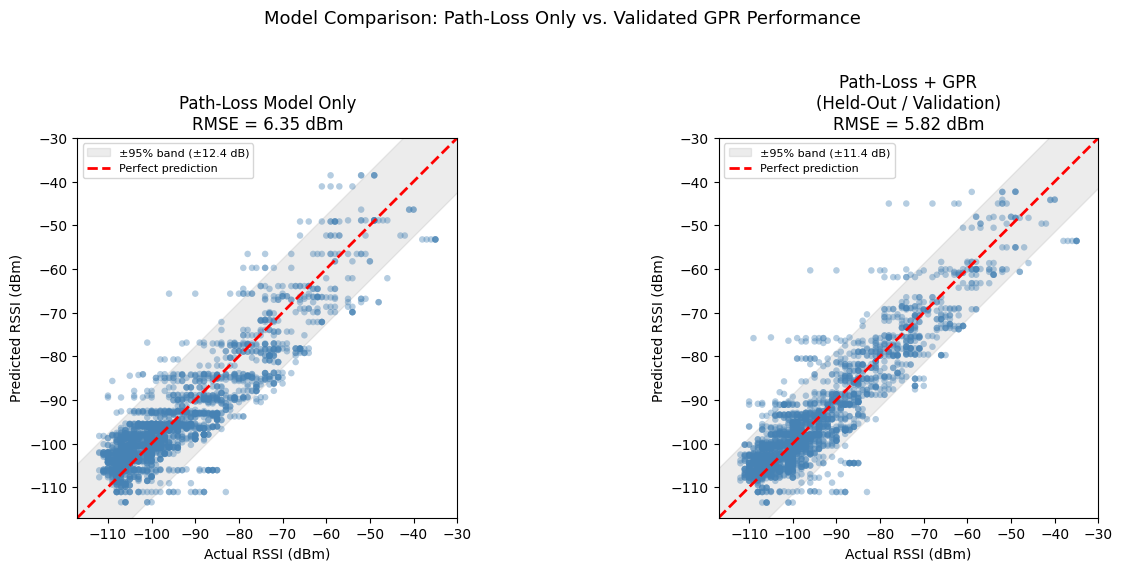

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

pl_pred_rssi = valid['pl_pred'].values
actual_rssi = valid['rssi'].values
cv_pred_rssi_hetero = pl_pred_rssi + cv_pred_residual_hetero
cv_rmse_check = np.sqrt(mean_squared_error(actual_rssi, cv_pred_rssi_hetero))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

panels = [
    (pl_pred_rssi, 'Path-Loss Model Only', pl_rmse),
    (cv_pred_rssi_hetero, 'Path-Loss + GPR\n(Held-Out / Validation)', cv_rmse_check),
]

for ax, (pred, title, rmse_val) in zip(axes, panels):
    lims = [actual_rssi.min() - 5, actual_rssi.max() + 5]
    line_x = np.linspace(lims[0], lims[1], 100)

    # Shaded confidence band around the perfect-prediction line, using
    # this model's own RMSE as the margin (~95% band = ±1.96*RMSE)
    band_95 = 1.96 * rmse_val
    ax.fill_between(line_x, line_x - band_95, line_x + band_95,
                     color='gray', alpha=0.15, label=f'±95% band (±{band_95:.1f} dB)')

    ax.scatter(actual_rssi, pred, alpha=0.4, s=22, color='steelblue', edgecolor='none')
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual RSSI (dBm)')
    ax.set_ylabel('Predicted RSSI (dBm)')
    ax.set_title(f'{title}\nRMSE = {rmse_val:.2f} dBm')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_aspect('equal')

plt.suptitle('Model Comparison: Path-Loss Only vs. Validated GPR Performance', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('presentation_scatter_2panel_hetero.png', dpi=200, bbox_inches='tight')
plt.show()

## 2D Physical Grid Threshold Contours From `clean_data.csv`

This section fits the requested 2D physical model using only `outputs/tests_gh_25_06/clean_data.csv`. It does not use `clean_data_for_worst_estimation.csv` and it does not include worst-case imputed loss points.

The model surface is fitted in physical greenhouse coordinates using `log10(distance from the gateway)` plus an effective row-crossing term `abs(y_m - gateway_y) / 1.65`. The threshold contours are drawn from this fitted model surface, not from direct interpolation of the measured data.

Two fits are compared:

- **Full clean-data fit:** all actual clean measurements in `clean_data.csv`.
- **Filtered clean-data fit:** the same `clean_data.csv` rows, filtered before fitting to `RSSI > -105 dBm` and `SNR > -3 dB`.

The filtered fit is useful for seeing the behavior of measurements that already satisfy the reliability thresholds, but it is optimistic for coverage because weak measurements are removed before fitting.


In [ ]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = Path("outputs/tests_gh_25_06")
MODEL_DATA_PATH = DATA_DIR / "clean_data.csv"
SUMMARY_PATH = DATA_DIR / "physical_2d_model_fit_summary.csv"
COEFFICIENTS_PATH = DATA_DIR / "physical_2d_model_coefficients.csv"
FIGURE_PATH = DATA_DIR / "physical_2d_model_threshold_contours.png"

ROW_SPACING_M = 1.65
GATEWAY_X_M = 3.3
GATEWAY_Y_M = 0.0
RSSI_THRESHOLD_DBM = -105.0
SNR_THRESHOLD_DB = -3.0

X_MIN_M, X_MAX_M = -162.0, 162.0
Y_MIN_M, Y_MAX_M = -138.6, 305.25
GRID_RES_M = 2.0


def load_model_data(path: Path) -> pd.DataFrame:
    data = pd.read_csv(path, low_memory=False)
    for col in ["x_m", "y_m", "rssi", "snr"]:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    return data.dropna(subset=["x_m", "y_m", "rssi", "snr"]).copy()


def physical_features(frame: pd.DataFrame) -> pd.DataFrame:
    dx = frame["x_m"].to_numpy(float) - GATEWAY_X_M
    dy = frame["y_m"].to_numpy(float) - GATEWAY_Y_M
    distance_m = np.sqrt(dx**2 + dy**2)
    distance_m = np.clip(distance_m, 1.0, None)
    return pd.DataFrame({
        "intercept": 1.0,
        "log10_distance_m": np.log10(distance_m),
        "effective_row_crossings": np.abs(dy) / ROW_SPACING_M,
    }, index=frame.index)


def fit_physical_ols(data: pd.DataFrame, metric: str, scenario: str) -> dict:
    fit_data = data.dropna(subset=[metric, "x_m", "y_m"]).copy()
    X_df = physical_features(fit_data)
    X = X_df.to_numpy(float)
    y = fit_data[metric].to_numpy(float)

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    resid = y - y_hat

    n, p = X.shape
    sse = float(np.sum(resid**2))
    tss = float(np.sum((y - y.mean())**2))
    rmse = float(np.sqrt(sse / n))
    mae = float(np.mean(np.abs(resid)))
    r2 = float(1 - sse / tss) if tss > 0 else np.nan
    adj_r2 = float(1 - (1 - r2) * (n - 1) / (n - p)) if n > p and np.isfinite(r2) else np.nan

    dof = n - p
    sigma2 = sse / dof if dof > 0 else np.nan
    cov = sigma2 * np.linalg.pinv(X.T @ X) if dof > 0 else np.full((p, p), np.nan)
    stderr = np.sqrt(np.diag(cov))
    t_stat = beta / stderr
    p_values = 2 * stats.t.sf(np.abs(t_stat), dof) if dof > 0 else np.full(p, np.nan)

    model_df = p - 1
    resid_df = n - p
    ms_model = (tss - sse) / model_df if model_df > 0 else np.nan
    ms_resid = sse / resid_df if resid_df > 0 else np.nan
    f_stat = ms_model / ms_resid if ms_resid and ms_resid > 0 else np.nan
    f_p_value = stats.f.sf(f_stat, model_df, resid_df) if np.isfinite(f_stat) else np.nan

    coefficients = pd.DataFrame({
        "source_csv": MODEL_DATA_PATH.name,
        "scenario": scenario,
        "metric": metric,
        "term": X_df.columns,
        "coefficient": beta,
        "std_error": stderr,
        "t_stat": t_stat,
        "p_value": p_values,
    })

    return {
        "source_csv": MODEL_DATA_PATH.name,
        "scenario": scenario,
        "metric": metric,
        "n": int(n),
        "p": int(p),
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "adj_r2": adj_r2,
        "f_stat": float(f_stat) if np.isfinite(f_stat) else np.nan,
        "f_p_value": float(f_p_value) if np.isfinite(f_p_value) else np.nan,
        "coefficients": coefficients,
        "beta": beta,
        "feature_columns": list(X_df.columns),
    }


def predict_grid(model: dict, grid: pd.DataFrame) -> np.ndarray:
    X_grid = physical_features(grid)[model["feature_columns"]].to_numpy(float)
    return X_grid @ model["beta"]


def make_prediction_grid() -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    x_grid = np.arange(X_MIN_M, X_MAX_M + GRID_RES_M, GRID_RES_M)
    y_grid = np.arange(Y_MIN_M, Y_MAX_M + GRID_RES_M, GRID_RES_M)
    xx, yy = np.meshgrid(x_grid, y_grid)
    grid = pd.DataFrame({"x_m": xx.ravel(), "y_m": yy.ravel()})
    return grid, xx, yy


def plot_threshold_contours(models: dict, grid: pd.DataFrame, xx: np.ndarray, yy: np.ndarray, training_sets: dict):
    fig, axes = plt.subplots(2, 2, figsize=(12, 16), constrained_layout=True)
    panels = [
        ("full_clean", "rssi", RSSI_THRESHOLD_DBM, "RSSI model (dBm)", "RdYlGn", (-125, -60)),
        ("full_clean", "snr", SNR_THRESHOLD_DB, "SNR model (dB)", "RdYlGn", (-18, 12)),
        ("filtered_clean", "rssi", RSSI_THRESHOLD_DBM, "RSSI model (dBm)", "RdYlGn", (-125, -60)),
        ("filtered_clean", "snr", SNR_THRESHOLD_DB, "SNR model (dB)", "RdYlGn", (-18, 12)),
    ]

    for ax, (scenario, metric, threshold, cbar_label, cmap, limits) in zip(axes.ravel(), panels):
        prediction = predict_grid(models[(scenario, metric)], grid).reshape(xx.shape)
        mesh = ax.pcolormesh(xx, yy, prediction, shading="auto", cmap=cmap, vmin=limits[0], vmax=limits[1])
        plt.colorbar(mesh, ax=ax, label=cbar_label)

        label_unit = "dBm" if metric == "rssi" else "dB"
        pred_min = float(np.nanmin(prediction))
        pred_max = float(np.nanmax(prediction))
        if pred_min <= threshold <= pred_max:
            contour = ax.contour(xx, yy, prediction, levels=[threshold], colors="black", linewidths=2.0)
            ax.clabel(contour, fmt={threshold: f"{threshold:g} {label_unit}"}, fontsize=9)
        else:
            side = "above" if pred_min > threshold else "below"
            ax.text(
                0.02, 0.02,
                f"No {threshold:g} {label_unit} contour in grid\nmodel stays {side} threshold",
                transform=ax.transAxes, ha="left", va="bottom", fontsize=9,
                bbox={"facecolor": "white", "edgecolor": "0.6", "alpha": 0.8},
            )

        train = training_sets[scenario]
        ax.scatter(train["x_m"], train["y_m"], s=7, c="black", alpha=0.24, linewidths=0, label="fit samples")
        ax.scatter(GATEWAY_X_M, GATEWAY_Y_M, marker="*", s=180, c="gold", edgecolor="black", linewidth=0.8, zorder=5, label="gateway")
        ax.set_xlim(X_MIN_M, X_MAX_M)
        ax.set_ylim(Y_MIN_M, Y_MAX_M)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x_m (m)")
        ax.set_ylabel("y_m (m)")
        title_scenario = "Full clean-data fit" if scenario == "full_clean" else "Filtered clean-data fit"
        title_metric = "RSSI" if metric == "rssi" else "SNR"
        ax.set_title(f"{title_scenario}: {title_metric} threshold contour")
        ax.legend(loc="upper right", fontsize=8)

    fig.savefig(FIGURE_PATH, dpi=170, bbox_inches="tight")
    plt.show()
    return fig


model_data = load_model_data(MODEL_DATA_PATH)
full_clean_data = model_data.copy()
filtered_clean_data = model_data[
    (model_data["rssi"] > RSSI_THRESHOLD_DBM)
    & (model_data["snr"] > SNR_THRESHOLD_DB)
].copy()

training_sets = {
    "full_clean": full_clean_data,
    "filtered_clean": filtered_clean_data,
}

models = {}
summary_rows = []
coefficient_tables = []
for scenario, fit_data in training_sets.items():
    for metric in ["rssi", "snr"]:
        result = fit_physical_ols(fit_data, metric, scenario)
        models[(scenario, metric)] = result
        summary_rows.append({key: value for key, value in result.items() if key not in {"coefficients", "beta", "feature_columns"}})
        coefficient_tables.append(result["coefficients"])

summary = pd.DataFrame(summary_rows)
coefficients = pd.concat(coefficient_tables, ignore_index=True)

grid, xx, yy = make_prediction_grid()
thresholds = {"rssi": RSSI_THRESHOLD_DBM, "snr": SNR_THRESHOLD_DB}
for idx, row in summary.iterrows():
    prediction = predict_grid(models[(row["scenario"], row["metric"])], grid)
    threshold = thresholds[row["metric"]]
    pred_min = float(np.nanmin(prediction))
    pred_max = float(np.nanmax(prediction))
    summary.loc[idx, "grid_prediction_min"] = pred_min
    summary.loc[idx, "grid_prediction_max"] = pred_max
    summary.loc[idx, "threshold"] = threshold
    summary.loc[idx, "threshold_crosses_grid"] = bool(pred_min <= threshold <= pred_max)

summary.to_csv(SUMMARY_PATH, index=False)
coefficients.to_csv(COEFFICIENTS_PATH, index=False)
physical_2d_contour_fig = plot_threshold_contours(models, grid, xx, yy, training_sets)

print(f"Fit data source: {MODEL_DATA_PATH.resolve()}")
print(f"Fit data: {len(full_clean_data)} full clean rows; {len(filtered_clean_data)} filtered clean rows.")
print(f"Saved contour figure to {FIGURE_PATH.resolve()}")
print(f"Saved fit summary to {SUMMARY_PATH.resolve()}")
print(f"Saved coefficient table to {COEFFICIENTS_PATH.resolve()}")

display(summary.round(4))
display(coefficients.round(5))


## Current 2D Physical-Fit Interpretation

These fits use `outputs/tests_gh_25_06/clean_data.csv` only. No worst-case imputed rows are included. The threshold curves are model contours, not contours drawn through the measured points. The model uses `log10(distance from the gateway)` and an effective row-crossing term computed with the fixed `1.65 m` row spacing.

Current results:

- **Full clean-data fit:** RSSI uses `2762` points, RMSE `5.39 dB`, `R^2 = 0.854`. SNR uses `2762` points, RMSE `5.22 dB`, `R^2 = 0.497`. The whole-model F-tests are significant (`p` effectively zero), so the physical surface explains more than a constant mean.
- **Filtered clean-data fit:** RSSI uses `1832` points, RMSE `5.51 dB`, `R^2 = 0.840`. SNR uses `1832` points, RMSE `3.40 dB`, `R^2 = 0.341`. This fit is conditional on already satisfying `RSSI > -105 dBm` and `SNR > -3 dB`, so it is optimistic for coverage.
- **Row-crossing significance:** in the full clean-data RSSI model, the row term is significant (`p < 0.001`, coefficient `0.057 dB` per effective row). In the full clean-data SNR model, the row term is also significant (`p < 0.001`, coefficient `-0.046 dB` per effective row). In the filtered clean fit, RSSI remains significant (`p < 0.001`) and SNR is still significant (`p = 0.0002`), but this interpretation is conditional on the threshold filter.
- **Contours:** the full clean-data model crosses both `-105 dBm` RSSI and `-3 dB` SNR inside the greenhouse grid. The filtered clean RSSI model crosses `-105 dBm`, but the filtered clean SNR model does **not** reach `-3 dB` anywhere in the grid; its predicted minimum is `1.95 dB`. That happens because the fit was trained only on measurements already above the threshold.

For estimating a reliability boundary from the actual clean measurements, use the full clean-data contour. The filtered clean contour is a diagnostic of already-good packets, not a conservative range estimate.


In [ ]:

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle
from scipy.optimize import brentq

DATA_DIR = Path("outputs/tests_gh_25_06")
SNR_COEFFICIENTS_PATH = DATA_DIR / "physical_2d_model_coefficients.csv"
OPTIMIZATION_TABLE_PATH = DATA_DIR / "snr_gateway_coverage_optimization.csv"
OPTIMIZATION_CURVE_PATH = DATA_DIR / "snr_gateway_coverage_curve.png"
OPTIMIZATION_MAP_PATH = DATA_DIR / "snr_gateway_coverage_maps.png"
MANUAL_CONFIG_PATH = Path("manual_time_ranges.json")

SNR_SCENARIO_FOR_OPTIMIZATION = "full_clean"
SNR_THRESHOLD_DB = -3.0
ROW_SPACING_M = 1.65
MAX_GATEWAYS = 6
MIN_MARGINAL_GAIN_TO_KEEP = 1e-6
CANDIDATE_SPACING_M = 20.0
CANDIDATE_EDGE_MARGIN_M = 0.0
EVALUATION_GRID_RES_M = 2.0
MAP_COUNTS_TO_PLOT = list(range(1, MAX_GATEWAYS + 1))


def greenhouse_rectangle() -> dict:
    config = json.loads(MANUAL_CONFIG_PATH.read_text(encoding="utf-8"))
    region = config.get("heatmap_region_m", {})
    return {
        "x_min": float(region.get("x_min", -162.0)),
        "x_max": float(region.get("x_max", 162.0)),
        "y_min": float(region.get("y_min", -138.6)),
        "y_max": float(region.get("y_max", 305.25)),
    }


def load_snr_physical_coefficients(path: Path, scenario: str) -> dict:
    coeffs = pd.read_csv(path)
    selected = coeffs[(coeffs["scenario"].eq(scenario)) & (coeffs["metric"].eq("snr"))]
    if selected.empty:
        raise ValueError(f"No SNR coefficients found for scenario={scenario!r} in {path}")
    return selected.set_index("term")["coefficient"].to_dict()


def snr_threshold_ellipse_axes(coefficients: dict, threshold_db: float) -> tuple[float, float]:
    intercept = float(coefficients["intercept"])
    log_coef = float(coefficients["log10_distance_m"])
    row_coef = float(coefficients["effective_row_crossings"])

    # Along x, there are zero row crossings, so the contour radius is analytic.
    x_radius = 10 ** ((threshold_db - intercept) / log_coef)

    # Along y, distance and row crossings both change. Solve the same physical
    # SNR model for the positive y-axis intercept of the threshold contour.
    def y_axis_model(y_radius):
        y_radius = max(float(y_radius), 1.0)
        return intercept + log_coef * np.log10(y_radius) + row_coef * (y_radius / ROW_SPACING_M) - threshold_db

    high = max(10.0, x_radius, 100.0)
    while y_axis_model(high) > 0 and high < 10000:
        high *= 2
    y_radius = brentq(y_axis_model, 1.0, high)
    return float(x_radius), float(y_radius)


def make_grid(region: dict, resolution_m: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x_values = np.arange(region["x_min"], region["x_max"] + resolution_m, resolution_m)
    y_values = np.arange(region["y_min"], region["y_max"] + resolution_m, resolution_m)
    xx, yy = np.meshgrid(x_values, y_values)
    points = np.column_stack([xx.ravel(), yy.ravel()])
    return points, xx, yy


def make_gateway_candidates(region: dict, spacing_m: float, edge_margin_m: float = 0.0) -> pd.DataFrame:
    x_start = region["x_min"] + edge_margin_m
    x_stop = region["x_max"] - edge_margin_m
    y_start = region["y_min"] + edge_margin_m
    y_stop = region["y_max"] - edge_margin_m
    x_values = np.arange(x_start, x_stop + spacing_m, spacing_m)
    y_values = np.arange(y_start, y_stop + spacing_m, spacing_m)
    x_values = x_values[x_values <= x_stop + 1e-9]
    y_values = y_values[y_values <= y_stop + 1e-9]
    xx, yy = np.meshgrid(x_values, y_values)
    return pd.DataFrame({"candidate_id": np.arange(xx.size), "x_m": xx.ravel(), "y_m": yy.ravel()})


def ellipse_coverage_matrix(points: np.ndarray, candidates: pd.DataFrame, x_radius: float, y_radius: float) -> np.ndarray:
    px = points[:, 0][None, :]
    py = points[:, 1][None, :]
    gx = candidates["x_m"].to_numpy(float)[:, None]
    gy = candidates["y_m"].to_numpy(float)[:, None]
    normalized = ((px - gx) / x_radius) ** 2 + ((py - gy) / y_radius) ** 2
    return normalized <= 1.0


def greedy_gateway_optimization(coverage_by_candidate: np.ndarray, candidates: pd.DataFrame, max_gateways: int) -> tuple[pd.DataFrame, list[np.ndarray]]:
    covered = np.zeros(coverage_by_candidate.shape[1], dtype=bool)
    available = np.ones(coverage_by_candidate.shape[0], dtype=bool)
    rows = []
    coverage_history = []

    previous_fraction = 0.0
    for gateway_number in range(1, max_gateways + 1):
        candidate_indices = np.flatnonzero(available)
        union_fraction = np.logical_or(coverage_by_candidate[candidate_indices], covered).mean(axis=1)
        best_local_index = int(np.argmax(union_fraction))
        best_candidate_index = int(candidate_indices[best_local_index])
        best_fraction = float(union_fraction[best_local_index])
        marginal_gain = best_fraction - previous_fraction
        if marginal_gain < MIN_MARGINAL_GAIN_TO_KEEP:
            break

        covered = np.logical_or(covered, coverage_by_candidate[best_candidate_index])
        available[best_candidate_index] = False

        covered_fraction = float(covered.mean())
        chosen = candidates.iloc[best_candidate_index]
        rows.append({
            "gateway_number": gateway_number,
            "candidate_id": int(chosen["candidate_id"]),
            "x_m": float(chosen["x_m"]),
            "y_m": float(chosen["y_m"]),
            "covered_fraction": covered_fraction,
            "covered_percent": 100 * covered_fraction,
            "marginal_fraction_gain": covered_fraction - previous_fraction,
            "marginal_percent_gain": 100 * (covered_fraction - previous_fraction),
        })
        coverage_history.append(covered.copy())
        previous_fraction = covered_fraction

    return pd.DataFrame(rows), coverage_history


def plot_coverage_curve(results: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
    ax.plot(results["gateway_number"], results["covered_percent"], marker="o", color="tab:blue", linewidth=2)
    ax.bar(results["gateway_number"], results["marginal_percent_gain"], alpha=0.22, color="tab:green", label="new area added")
    for _, row in results.iterrows():
        ax.text(row["gateway_number"], row["covered_percent"] + 1.0, f"{row['covered_percent']:.1f}%", ha="center", fontsize=9)
    ax.set_xlabel("Number of gateways")
    ax.set_ylabel("Greenhouse area covered (%)")
    ax.set_title("SNR-derived coverage gain from additional gateways")
    ax.set_xticks(results["gateway_number"])
    ax.set_ylim(0, min(105, max(10, results["covered_percent"].max() + 8)))
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(loc="lower right")
    fig.savefig(OPTIMIZATION_CURVE_PATH, dpi=170, bbox_inches="tight")
    plt.show()
    return fig


def plot_coverage_maps(region: dict, xx: np.ndarray, yy: np.ndarray, results: pd.DataFrame, coverage_history: list[np.ndarray], x_radius: float, y_radius: float):
    plot_counts = [count for count in MAP_COUNTS_TO_PLOT if 1 <= count <= len(coverage_history)]
    ncols = min(3, len(plot_counts))
    nrows = int(np.ceil(len(plot_counts) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 6.8 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    extent = [region["x_min"], region["x_max"], region["y_min"], region["y_max"]]
    for ax, count in zip(axes, plot_counts):
        covered_grid = coverage_history[count - 1].reshape(xx.shape)
        ax.imshow(covered_grid.astype(float), origin="lower", extent=extent, cmap="Greens", alpha=0.65, vmin=0, vmax=1)
        ax.add_patch(Rectangle((region["x_min"], region["y_min"]), region["x_max"] - region["x_min"], region["y_max"] - region["y_min"], fill=False, edgecolor="black", linewidth=1.5))

        chosen = results.iloc[:count]
        for _, gateway in chosen.iterrows():
            ellipse = Ellipse((gateway["x_m"], gateway["y_m"]), width=2 * x_radius, height=2 * y_radius, fill=False, edgecolor="tab:blue", linewidth=1.5, alpha=0.75)
            ax.add_patch(ellipse)
            ax.scatter(gateway["x_m"], gateway["y_m"], marker="*", s=160, c="gold", edgecolor="black", linewidth=0.8, zorder=5)
            label_x = np.clip(gateway["x_m"] + 4.0, region["x_min"] + 6.0, region["x_max"] - 12.0)
            label_y = np.clip(gateway["y_m"] + 4.0, region["y_min"] + 6.0, region["y_max"] - 6.0)
            ax.text(label_x, label_y, f"{int(gateway['gateway_number'])}", va="center", fontsize=9, weight="bold")

        coverage_percent = results.iloc[count - 1]["covered_percent"]
        ax.set_title(f"{count} gateway(s): {coverage_percent:.1f}% covered")
        ax.set_xlim(region["x_min"], region["x_max"])
        ax.set_ylim(region["y_min"], region["y_max"])
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x_m (m)")
        ax.set_ylabel("y_m (m)")

    for ax in axes[len(plot_counts):]:
        ax.axis("off")

    fig.suptitle(f"Greedy gateway placement using SNR={SNR_THRESHOLD_DB:g} dB ellipse footprints", fontsize=14)
    fig.savefig(OPTIMIZATION_MAP_PATH, dpi=170, bbox_inches="tight")
    plt.show()
    return fig


region = greenhouse_rectangle()
snr_coefficients = load_snr_physical_coefficients(SNR_COEFFICIENTS_PATH, SNR_SCENARIO_FOR_OPTIMIZATION)
x_radius_m, y_radius_m = snr_threshold_ellipse_axes(snr_coefficients, SNR_THRESHOLD_DB)

evaluation_points, opt_xx, opt_yy = make_grid(region, EVALUATION_GRID_RES_M)
gateway_candidates = make_gateway_candidates(region, CANDIDATE_SPACING_M, CANDIDATE_EDGE_MARGIN_M)
coverage_by_candidate = ellipse_coverage_matrix(evaluation_points, gateway_candidates, x_radius_m, y_radius_m)

optimization_results, coverage_history = greedy_gateway_optimization(coverage_by_candidate, gateway_candidates, MAX_GATEWAYS)
optimization_results["source_snr_scenario"] = SNR_SCENARIO_FOR_OPTIMIZATION
optimization_results["snr_threshold_db"] = SNR_THRESHOLD_DB
optimization_results["ellipse_x_radius_m"] = x_radius_m
optimization_results["ellipse_y_radius_m"] = y_radius_m
optimization_results["candidate_spacing_m"] = CANDIDATE_SPACING_M
optimization_results["candidate_edge_margin_m"] = CANDIDATE_EDGE_MARGIN_M
optimization_results["evaluation_grid_res_m"] = EVALUATION_GRID_RES_M
optimization_results["stopped_after_no_added_area"] = len(optimization_results) < MAX_GATEWAYS
optimization_results.to_csv(OPTIMIZATION_TABLE_PATH, index=False)

coverage_curve_fig = plot_coverage_curve(optimization_results)
coverage_maps_fig = plot_coverage_maps(region, opt_xx, opt_yy, optimization_results, coverage_history, x_radius_m, y_radius_m)

print(f"SNR coefficient source: {SNR_COEFFICIENTS_PATH.resolve()}")
print(f"Using scenario: {SNR_SCENARIO_FOR_OPTIMIZATION}")
print(f"Approximate SNR={SNR_THRESHOLD_DB:g} dB ellipse axes: x radius = {x_radius_m:.1f} m, y radius = {y_radius_m:.1f} m")
print(f"Saved optimization table to {OPTIMIZATION_TABLE_PATH.resolve()}")
print(f"Saved coverage curve to {OPTIMIZATION_CURVE_PATH.resolve()}")
print(f"Saved coverage maps to {OPTIMIZATION_MAP_PATH.resolve()}")

display(optimization_results.round(3))


## Combined RSSI and SNR Gateway Coverage Optimization

Coverage is defined here as the **intersection** of the two fitted threshold areas:

- power condition: `RSSI >= -105 dBm`
- signal-to-noise condition: `SNR >= -3 dB`

The section first builds the exact combined threshold footprint from the physical models fitted on `clean_data.csv`. Then it approximates that combined footprint as one axis-aligned ellipse. The greedy optimizer places copies of that ellipse inside the greenhouse rectangle and reports how the covered area percentage increases as gateways are added.

The editable checking constants are at the top of the code cell: `MAX_GATEWAYS`, `CANDIDATE_SPACING_M`, `CANDIDATE_EDGE_MARGIN_M`, `EVALUATION_GRID_RES_M`, and `FOOTPRINT_GRID_RES_M`.


In [ ]:

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle
from scipy.optimize import brentq

DATA_DIR = Path("outputs/tests_gh_25_06")
PHYSICAL_COEFFICIENTS_PATH = DATA_DIR / "physical_2d_model_coefficients.csv"
COMBINED_OPTIMIZATION_TABLE_PATH = DATA_DIR / "combined_gateway_coverage_optimization.csv"
COMBINED_ELLIPSE_DIAGNOSTICS_PATH = DATA_DIR / "combined_gateway_coverage_ellipse_diagnostics.csv"
COMBINED_FOOTPRINT_PATH = DATA_DIR / "combined_gateway_coverage_footprint.png"
COMBINED_CURVE_PATH = DATA_DIR / "combined_gateway_coverage_curve.png"
COMBINED_MAP_PATH = DATA_DIR / "combined_gateway_coverage_maps.png"
MANUAL_CONFIG_PATH = Path("manual_time_ranges.json")

MODEL_SCENARIO_FOR_OPTIMIZATION = "full_clean"
RSSI_THRESHOLD_DBM = -105.0
SNR_THRESHOLD_DB = -3.0
ROW_SPACING_M = 1.65

MAX_GATEWAYS = 8
MIN_MARGINAL_GAIN_TO_KEEP = 1e-6
CANDIDATE_SPACING_M = 15.0
CANDIDATE_EDGE_MARGIN_M = 0.0
EVALUATION_GRID_RES_M = 2.0
FOOTPRINT_GRID_RES_M = 1.0
MAP_COUNTS_TO_PLOT = list(range(1, MAX_GATEWAYS + 1))


def greenhouse_rectangle() -> dict:
    config = json.loads(MANUAL_CONFIG_PATH.read_text(encoding="utf-8"))
    region = config.get("heatmap_region_m", {})
    return {
        "x_min": float(region.get("x_min", -162.0)),
        "x_max": float(region.get("x_max", 162.0)),
        "y_min": float(region.get("y_min", -138.6)),
        "y_max": float(region.get("y_max", 305.25)),
    }


def load_metric_coefficients(path: Path, scenario: str, metric: str) -> dict:
    coeffs = pd.read_csv(path)
    selected = coeffs[(coeffs["scenario"].eq(scenario)) & (coeffs["metric"].eq(metric))]
    if selected.empty:
        raise ValueError(f"No coefficients found for scenario={scenario!r}, metric={metric!r} in {path}")
    return selected.set_index("term")["coefficient"].to_dict()


def predict_metric_relative(coefficients: dict, dx, dy):
    distance_m = np.sqrt(np.asarray(dx, dtype=float) ** 2 + np.asarray(dy, dtype=float) ** 2)
    distance_m = np.clip(distance_m, 1.0, None)
    effective_rows = np.abs(np.asarray(dy, dtype=float)) / ROW_SPACING_M
    return (
        float(coefficients["intercept"])
        + float(coefficients["log10_distance_m"]) * np.log10(distance_m)
        + float(coefficients["effective_row_crossings"]) * effective_rows
    )


def threshold_axis_radius(coefficients: dict, threshold: float, axis: str) -> float:
    def shifted_prediction(radius_m):
        if axis == "x":
            return float(predict_metric_relative(coefficients, radius_m, 0.0) - threshold)
        if axis == "y":
            return float(predict_metric_relative(coefficients, 0.0, radius_m) - threshold)
        raise ValueError("axis must be 'x' or 'y'")

    if shifted_prediction(1.0) < 0:
        return 0.0
    high = 10.0
    while shifted_prediction(high) > 0 and high < 10000.0:
        high *= 2.0
    if high >= 10000.0 and shifted_prediction(high) > 0:
        return high
    return float(brentq(shifted_prediction, 1.0, high))


def combined_threshold_mask(rssi_coeffs: dict, snr_coeffs: dict, dx, dy):
    rssi_ok = predict_metric_relative(rssi_coeffs, dx, dy) >= RSSI_THRESHOLD_DBM
    snr_ok = predict_metric_relative(snr_coeffs, dx, dy) >= SNR_THRESHOLD_DB
    return rssi_ok & snr_ok


def approximate_combined_footprint_ellipse(rssi_coeffs: dict, snr_coeffs: dict) -> tuple[dict, pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:
    rssi_x = threshold_axis_radius(rssi_coeffs, RSSI_THRESHOLD_DBM, "x")
    rssi_y = threshold_axis_radius(rssi_coeffs, RSSI_THRESHOLD_DBM, "y")
    snr_x = threshold_axis_radius(snr_coeffs, SNR_THRESHOLD_DB, "x")
    snr_y = threshold_axis_radius(snr_coeffs, SNR_THRESHOLD_DB, "y")

    axis_intersection_x = min(rssi_x, snr_x)
    axis_intersection_y = min(rssi_y, snr_y)
    x_extent = max(20.0, axis_intersection_x * 1.35)
    y_extent = max(20.0, axis_intersection_y * 1.35)

    dx_values = np.arange(-x_extent, x_extent + FOOTPRINT_GRID_RES_M, FOOTPRINT_GRID_RES_M)
    dy_values = np.arange(-y_extent, y_extent + FOOTPRINT_GRID_RES_M, FOOTPRINT_GRID_RES_M)
    dx_grid, dy_grid = np.meshgrid(dx_values, dy_values)
    mask = combined_threshold_mask(rssi_coeffs, snr_coeffs, dx_grid, dy_grid)
    if not np.any(mask):
        raise ValueError("The combined RSSI/SNR threshold footprint is empty for the selected model and thresholds.")

    covered_dx = dx_grid[mask]
    covered_dy = dy_grid[mask]
    exact_intersection_area_m2 = float(mask.sum() * FOOTPRINT_GRID_RES_M ** 2)

    # Moment/area ellipse: aspect comes from the exact intersection footprint;
    # area is matched to the exact intersection area.
    var_x = float(np.mean(covered_dx ** 2))
    var_y = float(np.mean(covered_dy ** 2))
    ellipse_aspect = np.sqrt(var_x / var_y) if var_y > 0 else 1.0
    ellipse_y_radius = np.sqrt(exact_intersection_area_m2 / (np.pi * ellipse_aspect))
    ellipse_x_radius = ellipse_aspect * ellipse_y_radius
    ellipse_area_m2 = float(np.pi * ellipse_x_radius * ellipse_y_radius)

    diagnostics = {
        "source_coefficients": str(PHYSICAL_COEFFICIENTS_PATH),
        "scenario": MODEL_SCENARIO_FOR_OPTIMIZATION,
        "rssi_threshold_dbm": RSSI_THRESHOLD_DBM,
        "snr_threshold_db": SNR_THRESHOLD_DB,
        "rssi_x_axis_radius_m": rssi_x,
        "rssi_y_axis_radius_m": rssi_y,
        "snr_x_axis_radius_m": snr_x,
        "snr_y_axis_radius_m": snr_y,
        "intersection_x_axis_radius_m": axis_intersection_x,
        "intersection_y_axis_radius_m": axis_intersection_y,
        "exact_intersection_area_m2": exact_intersection_area_m2,
        "ellipse_x_radius_m": float(ellipse_x_radius),
        "ellipse_y_radius_m": float(ellipse_y_radius),
        "ellipse_area_m2": ellipse_area_m2,
        "ellipse_aspect_x_over_y": float(ellipse_aspect),
        "footprint_grid_res_m": FOOTPRINT_GRID_RES_M,
    }
    diagnostics_df = pd.DataFrame([diagnostics])
    return diagnostics, diagnostics_df, dx_grid, dy_grid, mask


def make_grid(region: dict, resolution_m: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x_values = np.arange(region["x_min"], region["x_max"] + resolution_m, resolution_m)
    y_values = np.arange(region["y_min"], region["y_max"] + resolution_m, resolution_m)
    xx, yy = np.meshgrid(x_values, y_values)
    points = np.column_stack([xx.ravel(), yy.ravel()])
    return points, xx, yy


def make_gateway_candidates(region: dict, spacing_m: float, edge_margin_m: float = 0.0) -> pd.DataFrame:
    x_start = region["x_min"] + edge_margin_m
    x_stop = region["x_max"] - edge_margin_m
    y_start = region["y_min"] + edge_margin_m
    y_stop = region["y_max"] - edge_margin_m
    x_values = np.arange(x_start, x_stop + spacing_m, spacing_m)
    y_values = np.arange(y_start, y_stop + spacing_m, spacing_m)
    x_values = x_values[x_values <= x_stop + 1e-9]
    y_values = y_values[y_values <= y_stop + 1e-9]
    xx, yy = np.meshgrid(x_values, y_values)
    return pd.DataFrame({"candidate_id": np.arange(xx.size), "x_m": xx.ravel(), "y_m": yy.ravel()})


def ellipse_coverage_matrix(points: np.ndarray, candidates: pd.DataFrame, x_radius: float, y_radius: float) -> np.ndarray:
    px = points[:, 0][None, :]
    py = points[:, 1][None, :]
    gx = candidates["x_m"].to_numpy(float)[:, None]
    gy = candidates["y_m"].to_numpy(float)[:, None]
    normalized = ((px - gx) / x_radius) ** 2 + ((py - gy) / y_radius) ** 2
    return normalized <= 1.0


def greedy_gateway_optimization(coverage_by_candidate: np.ndarray, candidates: pd.DataFrame, max_gateways: int) -> tuple[pd.DataFrame, list[np.ndarray]]:
    covered = np.zeros(coverage_by_candidate.shape[1], dtype=bool)
    available = np.ones(coverage_by_candidate.shape[0], dtype=bool)
    rows = []
    coverage_history = []

    previous_fraction = 0.0
    for gateway_number in range(1, max_gateways + 1):
        candidate_indices = np.flatnonzero(available)
        union_fraction = np.logical_or(coverage_by_candidate[candidate_indices], covered).mean(axis=1)
        best_local_index = int(np.argmax(union_fraction))
        best_candidate_index = int(candidate_indices[best_local_index])
        best_fraction = float(union_fraction[best_local_index])
        marginal_gain = best_fraction - previous_fraction
        if marginal_gain < MIN_MARGINAL_GAIN_TO_KEEP:
            break

        covered = np.logical_or(covered, coverage_by_candidate[best_candidate_index])
        available[best_candidate_index] = False

        covered_fraction = float(covered.mean())
        chosen = candidates.iloc[best_candidate_index]
        rows.append({
            "gateway_number": gateway_number,
            "candidate_id": int(chosen["candidate_id"]),
            "x_m": float(chosen["x_m"]),
            "y_m": float(chosen["y_m"]),
            "covered_fraction": covered_fraction,
            "covered_percent": 100 * covered_fraction,
            "marginal_fraction_gain": covered_fraction - previous_fraction,
            "marginal_percent_gain": 100 * (covered_fraction - previous_fraction),
        })
        coverage_history.append(covered.copy())
        previous_fraction = covered_fraction

    return pd.DataFrame(rows), coverage_history


def plot_combined_footprint(dx_grid: np.ndarray, dy_grid: np.ndarray, mask: np.ndarray, diagnostics: dict):
    fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
    ax.imshow(
        mask.astype(float),
        origin="lower",
        extent=[dx_grid.min(), dx_grid.max(), dy_grid.min(), dy_grid.max()],
        cmap="Greens",
        alpha=0.65,
        vmin=0,
        vmax=1,
    )
    ellipse = Ellipse(
        (0, 0),
        width=2 * diagnostics["ellipse_x_radius_m"],
        height=2 * diagnostics["ellipse_y_radius_m"],
        fill=False,
        edgecolor="tab:blue",
        linewidth=2.2,
        label="ellipse approximation",
    )
    ax.add_patch(ellipse)
    ax.axhline(0, color="0.4", linewidth=0.8)
    ax.axvline(0, color="0.4", linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx from gateway (m)")
    ax.set_ylabel("dy from gateway (m)")
    ax.set_title("Combined RSSI and SNR threshold footprint")
    ax.legend(loc="upper right")
    fig.savefig(COMBINED_FOOTPRINT_PATH, dpi=170, bbox_inches="tight")
    plt.show()
    return fig


def plot_coverage_curve(results: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
    ax.plot(results["gateway_number"], results["covered_percent"], marker="o", color="tab:blue", linewidth=2)
    ax.bar(results["gateway_number"], results["marginal_percent_gain"], alpha=0.22, color="tab:green", label="new area added")
    for _, row in results.iterrows():
        ax.text(row["gateway_number"], row["covered_percent"] + 1.0, f"{row['covered_percent']:.1f}%", ha="center", fontsize=9)
    ax.set_xlabel("Number of gateways")
    ax.set_ylabel("Greenhouse area covered (%)")
    ax.set_title("Coverage gain from combined RSSI/SNR ellipse footprints")
    ax.set_xticks(results["gateway_number"])
    ax.set_ylim(0, min(105, max(10, results["covered_percent"].max() + 8)))
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(loc="lower right")
    fig.savefig(COMBINED_CURVE_PATH, dpi=170, bbox_inches="tight")
    plt.show()
    return fig


def plot_coverage_maps(region: dict, xx: np.ndarray, yy: np.ndarray, results: pd.DataFrame, coverage_history: list[np.ndarray], x_radius: float, y_radius: float):
    plot_counts = [count for count in MAP_COUNTS_TO_PLOT if 1 <= count <= len(coverage_history)]
    ncols = min(3, len(plot_counts))
    nrows = int(np.ceil(len(plot_counts) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 6.8 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    extent = [region["x_min"], region["x_max"], region["y_min"], region["y_max"]]
    for ax, count in zip(axes, plot_counts):
        covered_grid = coverage_history[count - 1].reshape(xx.shape)
        ax.imshow(covered_grid.astype(float), origin="lower", extent=extent, cmap="Greens", alpha=0.65, vmin=0, vmax=1)
        ax.add_patch(Rectangle((region["x_min"], region["y_min"]), region["x_max"] - region["x_min"], region["y_max"] - region["y_min"], fill=False, edgecolor="black", linewidth=1.5))

        chosen = results.iloc[:count]
        for _, gateway in chosen.iterrows():
            ellipse = Ellipse((gateway["x_m"], gateway["y_m"]), width=2 * x_radius, height=2 * y_radius, fill=False, edgecolor="tab:blue", linewidth=1.5, alpha=0.75)
            ax.add_patch(ellipse)
            ax.scatter(gateway["x_m"], gateway["y_m"], marker="*", s=160, c="gold", edgecolor="black", linewidth=0.8, zorder=5)
            label_x = np.clip(gateway["x_m"] + 4.0, region["x_min"] + 6.0, region["x_max"] - 12.0)
            label_y = np.clip(gateway["y_m"] + 4.0, region["y_min"] + 6.0, region["y_max"] - 6.0)
            ax.text(label_x, label_y, f"{int(gateway['gateway_number'])}", va="center", fontsize=9, weight="bold")

        coverage_percent = results.iloc[count - 1]["covered_percent"]
        ax.set_title(f"{count} gateway(s): {coverage_percent:.1f}% covered")
        ax.set_xlim(region["x_min"], region["x_max"])
        ax.set_ylim(region["y_min"], region["y_max"])
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x_m (m)")
        ax.set_ylabel("y_m (m)")

    for ax in axes[len(plot_counts):]:
        ax.axis("off")

    fig.suptitle("Greedy gateway placement using combined RSSI/SNR ellipse footprints", fontsize=14)
    fig.savefig(COMBINED_MAP_PATH, dpi=170, bbox_inches="tight")
    plt.show()
    return fig


region = greenhouse_rectangle()
rssi_coefficients = load_metric_coefficients(PHYSICAL_COEFFICIENTS_PATH, MODEL_SCENARIO_FOR_OPTIMIZATION, "rssi")
snr_coefficients = load_metric_coefficients(PHYSICAL_COEFFICIENTS_PATH, MODEL_SCENARIO_FOR_OPTIMIZATION, "snr")
footprint_diagnostics, footprint_diagnostics_df, footprint_dx, footprint_dy, footprint_mask = approximate_combined_footprint_ellipse(rssi_coefficients, snr_coefficients)
footprint_diagnostics_df.to_csv(COMBINED_ELLIPSE_DIAGNOSTICS_PATH, index=False)
combined_footprint_fig = plot_combined_footprint(footprint_dx, footprint_dy, footprint_mask, footprint_diagnostics)

evaluation_points, opt_xx, opt_yy = make_grid(region, EVALUATION_GRID_RES_M)
gateway_candidates = make_gateway_candidates(region, CANDIDATE_SPACING_M, CANDIDATE_EDGE_MARGIN_M)
coverage_by_candidate = ellipse_coverage_matrix(
    evaluation_points,
    gateway_candidates,
    footprint_diagnostics["ellipse_x_radius_m"],
    footprint_diagnostics["ellipse_y_radius_m"],
)

optimization_results, coverage_history = greedy_gateway_optimization(coverage_by_candidate, gateway_candidates, MAX_GATEWAYS)
for key, value in footprint_diagnostics.items():
    if isinstance(value, (int, float, str, bool, np.floating, np.integer)):
        optimization_results[key] = value
optimization_results["candidate_spacing_m"] = CANDIDATE_SPACING_M
optimization_results["candidate_edge_margin_m"] = CANDIDATE_EDGE_MARGIN_M
optimization_results["evaluation_grid_res_m"] = EVALUATION_GRID_RES_M
optimization_results["stopped_after_no_added_area"] = len(optimization_results) < MAX_GATEWAYS
optimization_results.to_csv(COMBINED_OPTIMIZATION_TABLE_PATH, index=False)

combined_coverage_curve_fig = plot_coverage_curve(optimization_results)
combined_coverage_maps_fig = plot_coverage_maps(
    region,
    opt_xx,
    opt_yy,
    optimization_results,
    coverage_history,
    footprint_diagnostics["ellipse_x_radius_m"],
    footprint_diagnostics["ellipse_y_radius_m"],
)

print(f"Coefficient source: {PHYSICAL_COEFFICIENTS_PATH.resolve()}")
print(f"Using scenario: {MODEL_SCENARIO_FOR_OPTIMIZATION}")
print(f"RSSI axis radii: x={footprint_diagnostics['rssi_x_axis_radius_m']:.1f} m, y={footprint_diagnostics['rssi_y_axis_radius_m']:.1f} m")
print(f"SNR axis radii:  x={footprint_diagnostics['snr_x_axis_radius_m']:.1f} m, y={footprint_diagnostics['snr_y_axis_radius_m']:.1f} m")
print(f"Intersection ellipse approximation: x radius={footprint_diagnostics['ellipse_x_radius_m']:.1f} m, y radius={footprint_diagnostics['ellipse_y_radius_m']:.1f} m")
print(f"Saved footprint diagnostic to {COMBINED_FOOTPRINT_PATH.resolve()}")
print(f"Saved optimization table to {COMBINED_OPTIMIZATION_TABLE_PATH.resolve()}")
print(f"Saved coverage curve to {COMBINED_CURVE_PATH.resolve()}")
print(f"Saved coverage maps to {COMBINED_MAP_PATH.resolve()}")

display(footprint_diagnostics_df.round(3))
display(optimization_results.round(3))


## Current Combined Gateway Optimization Result

This corrected optimization uses the intersection of the `RSSI >= -105 dBm` and `SNR >= -3 dB` fitted threshold areas from the `full_clean` physical model fitted on `clean_data.csv`. The exact combined footprint is approximated by an equal-area, moment-aspect ellipse before placement optimization.

Current fitted threshold diagnostics:

- RSSI threshold axis radii: x `132.0 m`, y `186.5 m`.
- SNR threshold axis radii: x `451.9 m`, y `179.1 m`.
- Combined footprint exact area: `82857 m^2`.
- Ellipse approximation: x-radius `141.8 m`, y-radius `186.0 m`.

Coverage gain from the greedy placement:

- 1 gateway(s): `57.0%` covered; new area added `57.0%`; selected position `(-12.0, 56.4) m`.
- 2 gateway(s): `76.6%` covered; new area added `19.6%`; selected position `(33.0, 206.4) m`.
- 3 gateway(s): `87.3%` covered; new area added `10.7%`; selected position `(33.0, -48.6) m`.
- 4 gateway(s): `95.7%` covered; new area added `8.4%`; selected position `(-132.0, 116.4) m`.
- 5 gateway(s): `98.7%` covered; new area added `3.0%`; selected position `(-162.0, -138.6) m`.
- 6 gateway(s): `99.6%` covered; new area added `0.9%`; selected position `(123.0, 131.4) m`.
- 7 gateway(s): `100.0%` covered; new area added `0.3%`; selected position `(-132.0, 131.4) m`.
- 8 gateway(s): `100.0%` covered; new area added `0.0%`; selected position `(33.0, -138.6) m`.

The old SNR-only optimization is not the coverage definition. Use these `combined_gateway_coverage_*` outputs for the gateway placement analysis.
